# 04 — `evaluate`

```
evaluate.py
===========
Evaluasi model YOLO26 (object detection) terlatih pada validation & test set.

Alur:
  - muat best weights
  - evaluasi validation (model.val split='val')
  - evaluasi test bila tersedia (split='test')
  - bandingkan val vs test (indikasi overfitting / pergeseran distribusi)
  - prediksi beberapa sample gambar test -> simpan gambar beranotasi
  - tulis metrik + interpretasi otomatis

Jalankan dari ROOT project (Windows):
    python src/evaluate.py --weights runs/train/helmet_yolo26s_baseline/weights/best.pt --data dataset/data.yaml
    python src/evaluate.py --allow-cpu        # izinkan evaluasi di CPU bila CUDA tak ada

Output (runs/evaluate/):
  val_metrics.csv, test_metrics.csv, evaluation_summary.txt, predictions/

Catatan: metrik dihitung pada conf yang dipilih (default 0.25 = titik operasi).
Untuk mAP benchmark standar gunakan --conf 0.001. READ-ONLY terhadap dataset.
```

Notebook ini adalah versi notebook dari [`src/evaluate.py`](../src/evaluate.py). Jalankan sel berurutan dari atas.

## Setup

In [1]:
# === Setup — jalankan sel ini lebih dulu ===
# Menemukan root project, menambahkan src/ ke sys.path, dan pindah (chdir) ke root
# agar semua path relatif (dataset/..., runs/...) berperilaku sama seperti
# menjalankan script dari root project.
import os, sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / "src").is_dir() and (d / "dataset").exists():
            return d
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("cwd         :", Path.cwd())

PROJECT_ROOT: D:\ML\test-code\construction-safety-helmet-yolo26
cwd         : D:\ML\test-code\construction-safety-helmet-yolo26


## Definisi kode (dari `src/evaluate.py`)

In [ ]:
from __future__ import annotations

import argparse
import csv
import sys
from datetime import datetime
from pathlib import Path

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

DEFAULTS = {
    "weights": "runs/train/helmet_yolo26s_baseline/weights/best.pt",
    "data": "dataset/data.yaml",
    "imgsz": 640,
    "conf": 0.25,
    "iou": 0.5,
    "device": "0",
    "output": "runs/evaluate",
    "num_samples": 12,
}


def _line(char: str = "=", width: int = 64) -> str:
    return char * width


# --------------------------------------------------------------------------- #
# Dataset config & resolusi path
# --------------------------------------------------------------------------- #
def load_yaml(path: Path) -> dict:
    import yaml
    with path.open("r", encoding="utf-8") as fh:
        return yaml.safe_load(fh) or {}


def resolve_images_dir(root: Path, data: dict, key_cands: list[str],
                       folder_cands: list[str]) -> Path | None:
    """Resolusi folder images sebuah split (tahan '../' Roboflow & valid/val)."""
    raw = next((data.get(k) for k in key_cands if data.get(k)), None)
    if isinstance(raw, str) and raw.strip():
        cand = (root / raw).resolve()
        if cand.is_dir():
            return cand
        stripped = raw
        while stripped.startswith("../"):
            stripped = stripped[3:]
        cand2 = (root / stripped).resolve()
        if cand2.is_dir():
            return cand2
    for name in folder_cands:
        cand = root / name / "images"
        if cand.is_dir():
            return cand
    return None


def list_images(images_dir: Path) -> list[Path]:
    return sorted(p for p in images_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS)


# --------------------------------------------------------------------------- #
# Device
# --------------------------------------------------------------------------- #
def resolve_device(device_arg, allow_cpu: bool) -> tuple[object, bool, str]:
    """Return (device, ok, label). ok=False bila GPU diminta tapi CUDA tak ada & tanpa --allow-cpu."""
    try:
        import torch
    except ImportError as exc:
        raise RuntimeError("PyTorch belum terinstal. Instal PyTorch CUDA dari pytorch.org.") from exc

    if str(device_arg).lower() == "cpu":
        return "cpu", True, "CPU (diminta)"

    if torch.cuda.is_available():
        idx = int(device_arg) if str(device_arg).isdigit() else 0
        try:
            name = torch.cuda.get_device_properties(idx).name
        except Exception:
            name = "GPU"
        return device_arg, True, name

    # CUDA tidak tersedia
    if allow_cpu:
        print("[PERINGATAN] CUDA tidak tersedia. Melanjutkan di CPU (--allow-cpu). Akan lebih lambat.")
        return "cpu", True, "CPU (fallback --allow-cpu)"
    return device_arg, False, ""


# --------------------------------------------------------------------------- #
# Ekstraksi metrik
# --------------------------------------------------------------------------- #
def _f(v):
    try:
        return float(v)
    except (TypeError, ValueError):
        return None


def extract_overall(metrics) -> dict:
    p = r = m50 = m95 = None
    box = getattr(metrics, "box", None)
    if box is not None:
        p, r = getattr(box, "mp", None), getattr(box, "mr", None)
        m50, m95 = getattr(box, "map50", None), getattr(box, "map", None)
    rd = getattr(metrics, "results_dict", None)
    if isinstance(rd, dict):
        p = p if p is not None else rd.get("metrics/precision(B)")
        r = r if r is not None else rd.get("metrics/recall(B)")
        m50 = m50 if m50 is not None else rd.get("metrics/mAP50(B)")
        m95 = m95 if m95 is not None else rd.get("metrics/mAP50-95(B)")
    return {"precision": _f(p), "recall": _f(r), "map50": _f(m50), "map5095": _f(m95)}


def extract_per_class(metrics, names) -> list[tuple]:
    """Return list (class_name, precision, recall, map50, map50-95)."""
    out: list[tuple] = []
    box = getattr(metrics, "box", None)
    if box is None:
        return out
    try:
        idxs = list(getattr(box, "ap_class_index", []) or [])
        for i, cid in enumerate(idxs):
            cid = int(cid)
            if isinstance(names, dict):
                cname = names.get(cid, str(cid))
            elif isinstance(names, (list, tuple)) and cid < len(names):
                cname = names[cid]
            else:
                cname = str(cid)
            out.append((cname, _f(box.p[i]), _f(box.r[i]), _f(box.ap50[i]), _f(box.ap[i])))
    except Exception:
        pass
    return out


def write_metrics_csv(path: Path, overall: dict, per_class: list[tuple]) -> None:
    with path.open("w", newline="", encoding="utf-8") as fh:
        w = csv.writer(fh)
        w.writerow(["scope", "precision", "recall", "mAP50", "mAP50-95"])
        w.writerow(["overall",
                    _round(overall["precision"]), _round(overall["recall"]),
                    _round(overall["map50"]), _round(overall["map5095"])])
        for cname, p, r, m50, m95 in per_class:
            w.writerow([cname, _round(p), _round(r), _round(m50), _round(m95)])


def _round(v, nd=4):
    return round(v, nd) if isinstance(v, (int, float)) else "N/A"


# --------------------------------------------------------------------------- #
# Interpretasi otomatis
# --------------------------------------------------------------------------- #
def interpret_split(label: str, m: dict) -> list[str]:
    notes = []
    p, r, m50, m95 = m["precision"], m["recall"], m["map50"], m["map5095"]
    if None not in (p, r):
        if p - r >= 0.15:
            notes.append(f"[{label}] Precision ({p:.3f}) >> Recall ({r:.3f}): model cenderung "
                         "MELEWATKAN sebagian objek (konservatif).")
        elif r - p >= 0.15:
            notes.append(f"[{label}] Recall ({r:.3f}) >> Precision ({p:.3f}): model cenderung "
                         "menghasilkan FALSE POSITIVE.")
        else:
            notes.append(f"[{label}] Precision ({p:.3f}) & Recall ({r:.3f}) relatif seimbang.")
    if None not in (m50, m95):
        if m50 >= 0.5 and (m50 - m95) >= 0.20:
            notes.append(f"[{label}] mAP50 ({m50:.3f}) >> mAP50-95 ({m95:.3f}): objek dikenali "
                         "namun BOUNDING BOX belum cukup presisi.")
        else:
            notes.append(f"[{label}] Selisih mAP50 ({m50:.3f}) vs mAP50-95 ({m95:.3f}) wajar.")
    return notes


def interpret_gap(val_m: dict, test_m: dict) -> list[str]:
    vm, tm = val_m["map5095"], test_m["map5095"]
    if None in (vm, tm):
        return ["[val vs test] mAP50-95 tidak lengkap; perbandingan dilewati."]
    gap = vm - tm
    if gap >= 0.10:
        return [f"[val vs test] Test (mAP50-95={tm:.3f}) JAUH lebih rendah dari val ({vm:.3f}, "
                f"selisih {gap:.3f}): indikasi OVERFITTING atau perbedaan distribusi data train/test."]
    if gap <= -0.05:
        return [f"[val vs test] Test ({tm:.3f}) lebih TINGGI dari val ({vm:.3f}); "
                "tidak biasa, cek apakah val lebih sulit / lebih padat objek."]
    return [f"[val vs test] Performa konsisten (selisih mAP50-95 {gap:.3f}); generalisasi baik."]


# --------------------------------------------------------------------------- #
# Summary
# --------------------------------------------------------------------------- #
def fmt_metrics(m: dict) -> str:
    def g(k):
        v = m[k]
        return f"{v:.4f}" if isinstance(v, (int, float)) else "N/A"
    return (f"precision={g('precision')}  recall={g('recall')}  "
            f"mAP50={g('map50')}  mAP50-95={g('map5095')}")


def build_summary(args, device_label, val_m, test_m, test_available,
                  n_predictions, pred_dir) -> str:
    L: list[str] = []
    L.append(_line())
    L.append("RINGKASAN EVALUASI - YOLO26s (object detection)")
    L.append(_line())
    L.append(f"Waktu        : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    L.append(f"Weights      : {args.weights}")
    L.append(f"Data         : {args.data}")
    L.append(f"imgsz        : {args.imgsz}   conf: {args.conf}   iou: {args.iou}")
    L.append(f"Device       : {args.device} ({device_label})")
    L.append("")
    L.append("METRIK VALIDATION SET")
    L.append("-" * 64)
    L.append(f"  {fmt_metrics(val_m)}")
    L.append("")
    L.append("METRIK TEST SET")
    L.append("-" * 64)
    if test_available:
        L.append(f"  {fmt_metrics(test_m)}")
    else:
        L.append("  TEST SET TIDAK TERSEDIA di data.yaml (atau folder kosong) -> evaluasi test dilewati.")
    L.append("")

    if test_available:
        L.append("PERBANDINGAN VAL vs TEST")
        L.append("-" * 64)
        L.append(f"  {'metric':<12}{'val':>10}{'test':>10}{'delta(val-test)':>18}")
        for key, lbl in [("precision", "precision"), ("recall", "recall"),
                          ("map50", "mAP50"), ("map5095", "mAP50-95")]:
            v, t = val_m[key], test_m[key]
            d = (v - t) if None not in (v, t) else None
            L.append(f"  {lbl:<12}{_s(v):>10}{_s(t):>10}{_s(d):>18}")
        L.append("")

    L.append("INTERPRETASI OTOMATIS")
    L.append("-" * 64)
    notes = interpret_split("VAL", val_m)
    if test_available:
        notes += interpret_split("TEST", test_m)
        notes += interpret_gap(val_m, test_m)
    for n in notes:
        L.append(f"- {n}")
    L.append("")
    L.append("PEDOMAN INTERPRETASI")
    L.append("-" * 64)
    L.append("1. Precision tinggi & recall rendah  -> model melewatkan sebagian objek.")
    L.append("2. Recall tinggi & precision rendah  -> model menghasilkan banyak false positive.")
    L.append("3. mAP50 tinggi & mAP50-95 rendah    -> bounding box belum cukup presisi.")
    L.append("4. Test jauh < validation            -> indikasi overfitting / beda distribusi data.")
    L.append("")
    L.append(f"Sample prediksi : {n_predictions} gambar -> {pred_dir}")
    L.append(_line())
    return "\n".join(L)


def _s(v):
    return f"{v:.4f}" if isinstance(v, (int, float)) else "N/A"


# --------------------------------------------------------------------------- #
# Main
# --------------------------------------------------------------------------- #
def parse_args(argv: list[str] | None = None) -> argparse.Namespace:
    p = argparse.ArgumentParser(description="Evaluasi model YOLO26 (val & test) + sample prediksi.")
    p.add_argument("--weights", default=DEFAULTS["weights"], help="Path best.pt.")
    p.add_argument("--data", default=DEFAULTS["data"], help="Path data.yaml (default: dataset/data.yaml).")
    p.add_argument("--imgsz", type=int, default=DEFAULTS["imgsz"])
    p.add_argument("--conf", type=float, default=DEFAULTS["conf"], help="Confidence threshold (default 0.25).")
    p.add_argument("--iou", type=float, default=DEFAULTS["iou"], help="IoU threshold NMS (default 0.5).")
    p.add_argument("--device", default=DEFAULTS["device"], help="0 untuk GPU, 'cpu' untuk CPU.")
    p.add_argument("--output", "-o", default=DEFAULTS["output"], help="Folder output (default runs/evaluate).")
    p.add_argument("--num-samples", type=int, default=DEFAULTS["num_samples"],
                   help="Jumlah sample gambar untuk prediksi visual (default 12).")
    p.add_argument("--allow-cpu", action="store_true", help="Izinkan evaluasi di CPU bila CUDA tak ada.")
    return p.parse_args(argv)


def main(argv: list[str] | None = None) -> int:
    args = parse_args(argv)
    # Absolut: Ultralytics me-resolve project RELATIF ke RUNS_DIR/task/project (runs/detect/...).
    # Path absolut menjaga output tetap di runs/evaluate/ sesuai spesifikasi.
    out_dir = Path(args.output).resolve()
    pred_dir = out_dir / "predictions"

    print(_line())
    print("EVALUASI YOLO26s - Construction Safety Helmet")
    print(_line())

    # 4) Validasi weights
    weights = Path(args.weights)
    if not weights.is_file():
        print(f"[ERROR] Weights tidak ditemukan: {weights}")
        print("        Latih model dulu (src/train.py) atau berikan --weights yang benar.")
        return 2

    # Validasi data.yaml
    data_path = Path(args.data)
    if not data_path.is_file():
        print(f"[ERROR] data.yaml tidak ditemukan: {data_path}")
        return 2

    # 6) Device
    try:
        device, device_ok, device_label = resolve_device(args.device, args.allow_cpu)
    except RuntimeError as exc:
        print(f"[ERROR] {exc}")
        return 2
    if not device_ok:
        print(f"[ERROR] CUDA tidak tersedia (device={args.device}). "
              "Tambahkan --allow-cpu untuk evaluasi di CPU, atau perbaiki instalasi CUDA.")
        return 2
    print(f"Device: {args.device} ({device_label})")

    # Deteksi ketersediaan test set
    try:
        data = load_yaml(data_path)
    except Exception as exc:
        print(f"[ERROR] Gagal membaca data.yaml: {exc}")
        return 2
    root = data_path.parent.resolve()
    test_dir = resolve_images_dir(root, data, ["test"], ["test"])
    val_dir = resolve_images_dir(root, data, ["val", "valid"], ["valid", "val"])
    test_available = test_dir is not None and len(list_images(test_dir)) > 0

    # Muat model
    try:
        from ultralytics import YOLO
    except ImportError as exc:
        print(f"[ERROR] Ultralytics belum terinstal: {exc}")
        return 2
    print(f"\nMemuat model: {weights}")
    try:
        model = YOLO(str(weights), task="detect")
    except Exception as exc:
        print(f"[ERROR] Gagal memuat model: {exc}")
        return 2

    common = dict(data=str(data_path), imgsz=args.imgsz, conf=args.conf,
                  iou=args.iou, device=device, plots=True, exist_ok=True)

    # 2) Evaluasi validation
    print("\n" + _line("-"))
    print("Evaluasi VALIDATION set ...")
    print(_line("-"))
    try:
        val_metrics = model.val(split="val", project=str(out_dir), name="val", **common)
    except Exception as exc:
        print(f"[ERROR] Evaluasi validation gagal: {exc}")
        return 1
    val_m = extract_overall(val_metrics)
    val_pc = extract_per_class(val_metrics, model.names)
    out_dir.mkdir(parents=True, exist_ok=True)
    write_metrics_csv(out_dir / "val_metrics.csv", val_m, val_pc)
    print(f"  -> {fmt_metrics(val_m)}")

    # 3) Evaluasi test (bila ada)
    test_m = {"precision": None, "recall": None, "map50": None, "map5095": None}
    if test_available:
        print("\n" + _line("-"))
        print("Evaluasi TEST set ...")
        print(_line("-"))
        try:
            test_metrics = model.val(split="test", project=str(out_dir), name="test", **common)
            test_m = extract_overall(test_metrics)
            test_pc = extract_per_class(test_metrics, model.names)
            write_metrics_csv(out_dir / "test_metrics.csv", test_m, test_pc)
            print(f"  -> {fmt_metrics(test_m)}")
        except Exception as exc:
            print(f"[PERINGATAN] Evaluasi test gagal: {exc}")
            test_available = False
            write_metrics_csv(out_dir / "test_metrics.csv", test_m, [])
    else:
        print("\n[INFO] Test set tidak tersedia -> evaluasi test dilewati.")
        write_metrics_csv(out_dir / "test_metrics.csv", test_m, [])

    # 7-8) Prediksi sample gambar
    sample_src_dir = test_dir if test_available else val_dir
    n_predictions = 0
    if sample_src_dir is not None:
        images = list_images(sample_src_dir)
        if images:
            import random
            random.seed(42)
            k = min(args.num_samples, len(images))
            samples = random.sample(images, k)
            print("\n" + _line("-"))
            print(f"Prediksi {k} sample gambar dari: {sample_src_dir.name} ...")
            print(_line("-"))
            try:
                model.predict(source=[str(p) for p in samples], imgsz=args.imgsz,
                              conf=args.conf, iou=args.iou, device=device, save=True,
                              project=str(out_dir), name="predictions", exist_ok=True, verbose=False)
                n_predictions = k
            except Exception as exc:
                print(f"[PERINGATAN] Prediksi sample gagal: {exc}")
    else:
        print("[PERINGATAN] Tidak ada folder gambar untuk sampel prediksi.")

    # Summary
    summary = build_summary(args, device_label, val_m, test_m, test_available,
                            n_predictions, pred_dir)
    (out_dir / "evaluation_summary.txt").write_text(summary, encoding="utf-8")
    print("\n")
    print(summary)
    print(f"\nOutput tersimpan di: {out_dir}")
    return 0

## Jalankan
> Membutuhkan `best.pt` hasil training. Tambahkan `--allow-cpu` bila tanpa GPU.

Argumen di bawah setara dengan opsi CLI. Edit sesuai kebutuhan.

In [ ]:
rc = main(["--weights", "runs/train/helmet_yolo26s_baseline/weights/best.pt",
      "--data", "dataset/data.yaml"])
print("exit code:", rc)

## Analisis hasil & *kenapa* model salah
> ⚠️ **Catatan:** bila `best.pt` berasal dari *training DEMO* (subset kecil, sedikit epoch), angka di bawah **tidak mencerminkan performa nyata** — hanya untuk menunjukkan bentuk visualisasinya.

### a. Metrik per kelas — *kenapa* sebagian kelas underperform

In [2]:
from pathlib import Path
import pandas as pd, matplotlib.pyplot as plt
out = Path("runs/evaluate")
def per_class(csv, label):
    p = out / csv
    if not p.exists(): print(f"{csv} belum ada — jalankan sel Run dulu."); return
    d = pd.read_csv(p)
    for c in ["precision","recall","mAP50","mAP50-95"]:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    pc = d[d["scope"] != "overall"]
    if pc.empty: print("tak ada metrik per-kelas di", csv); return
    ax = pc.set_index("scope")[["precision","recall","mAP50","mAP50-95"]].plot.bar(figsize=(9,4))
    ax.set_title(f"Metrik per kelas — {label}"); ax.set_ylim(0,1); ax.set_xlabel("kelas")
    ax.tick_params(axis="x", rotation=0); plt.tight_layout(); plt.show(); display(d)
per_class("val_metrics.csv", "VALIDATION")
per_class("test_metrics.csv", "TEST")

tak ada metrik per-kelas di val_metrics.csv
tak ada metrik per-kelas di test_metrics.csv


### b. Plot diagnostik Ultralytics — confusion matrix & kurva P/R/F1

=== val ===
BoxF1_curve.png


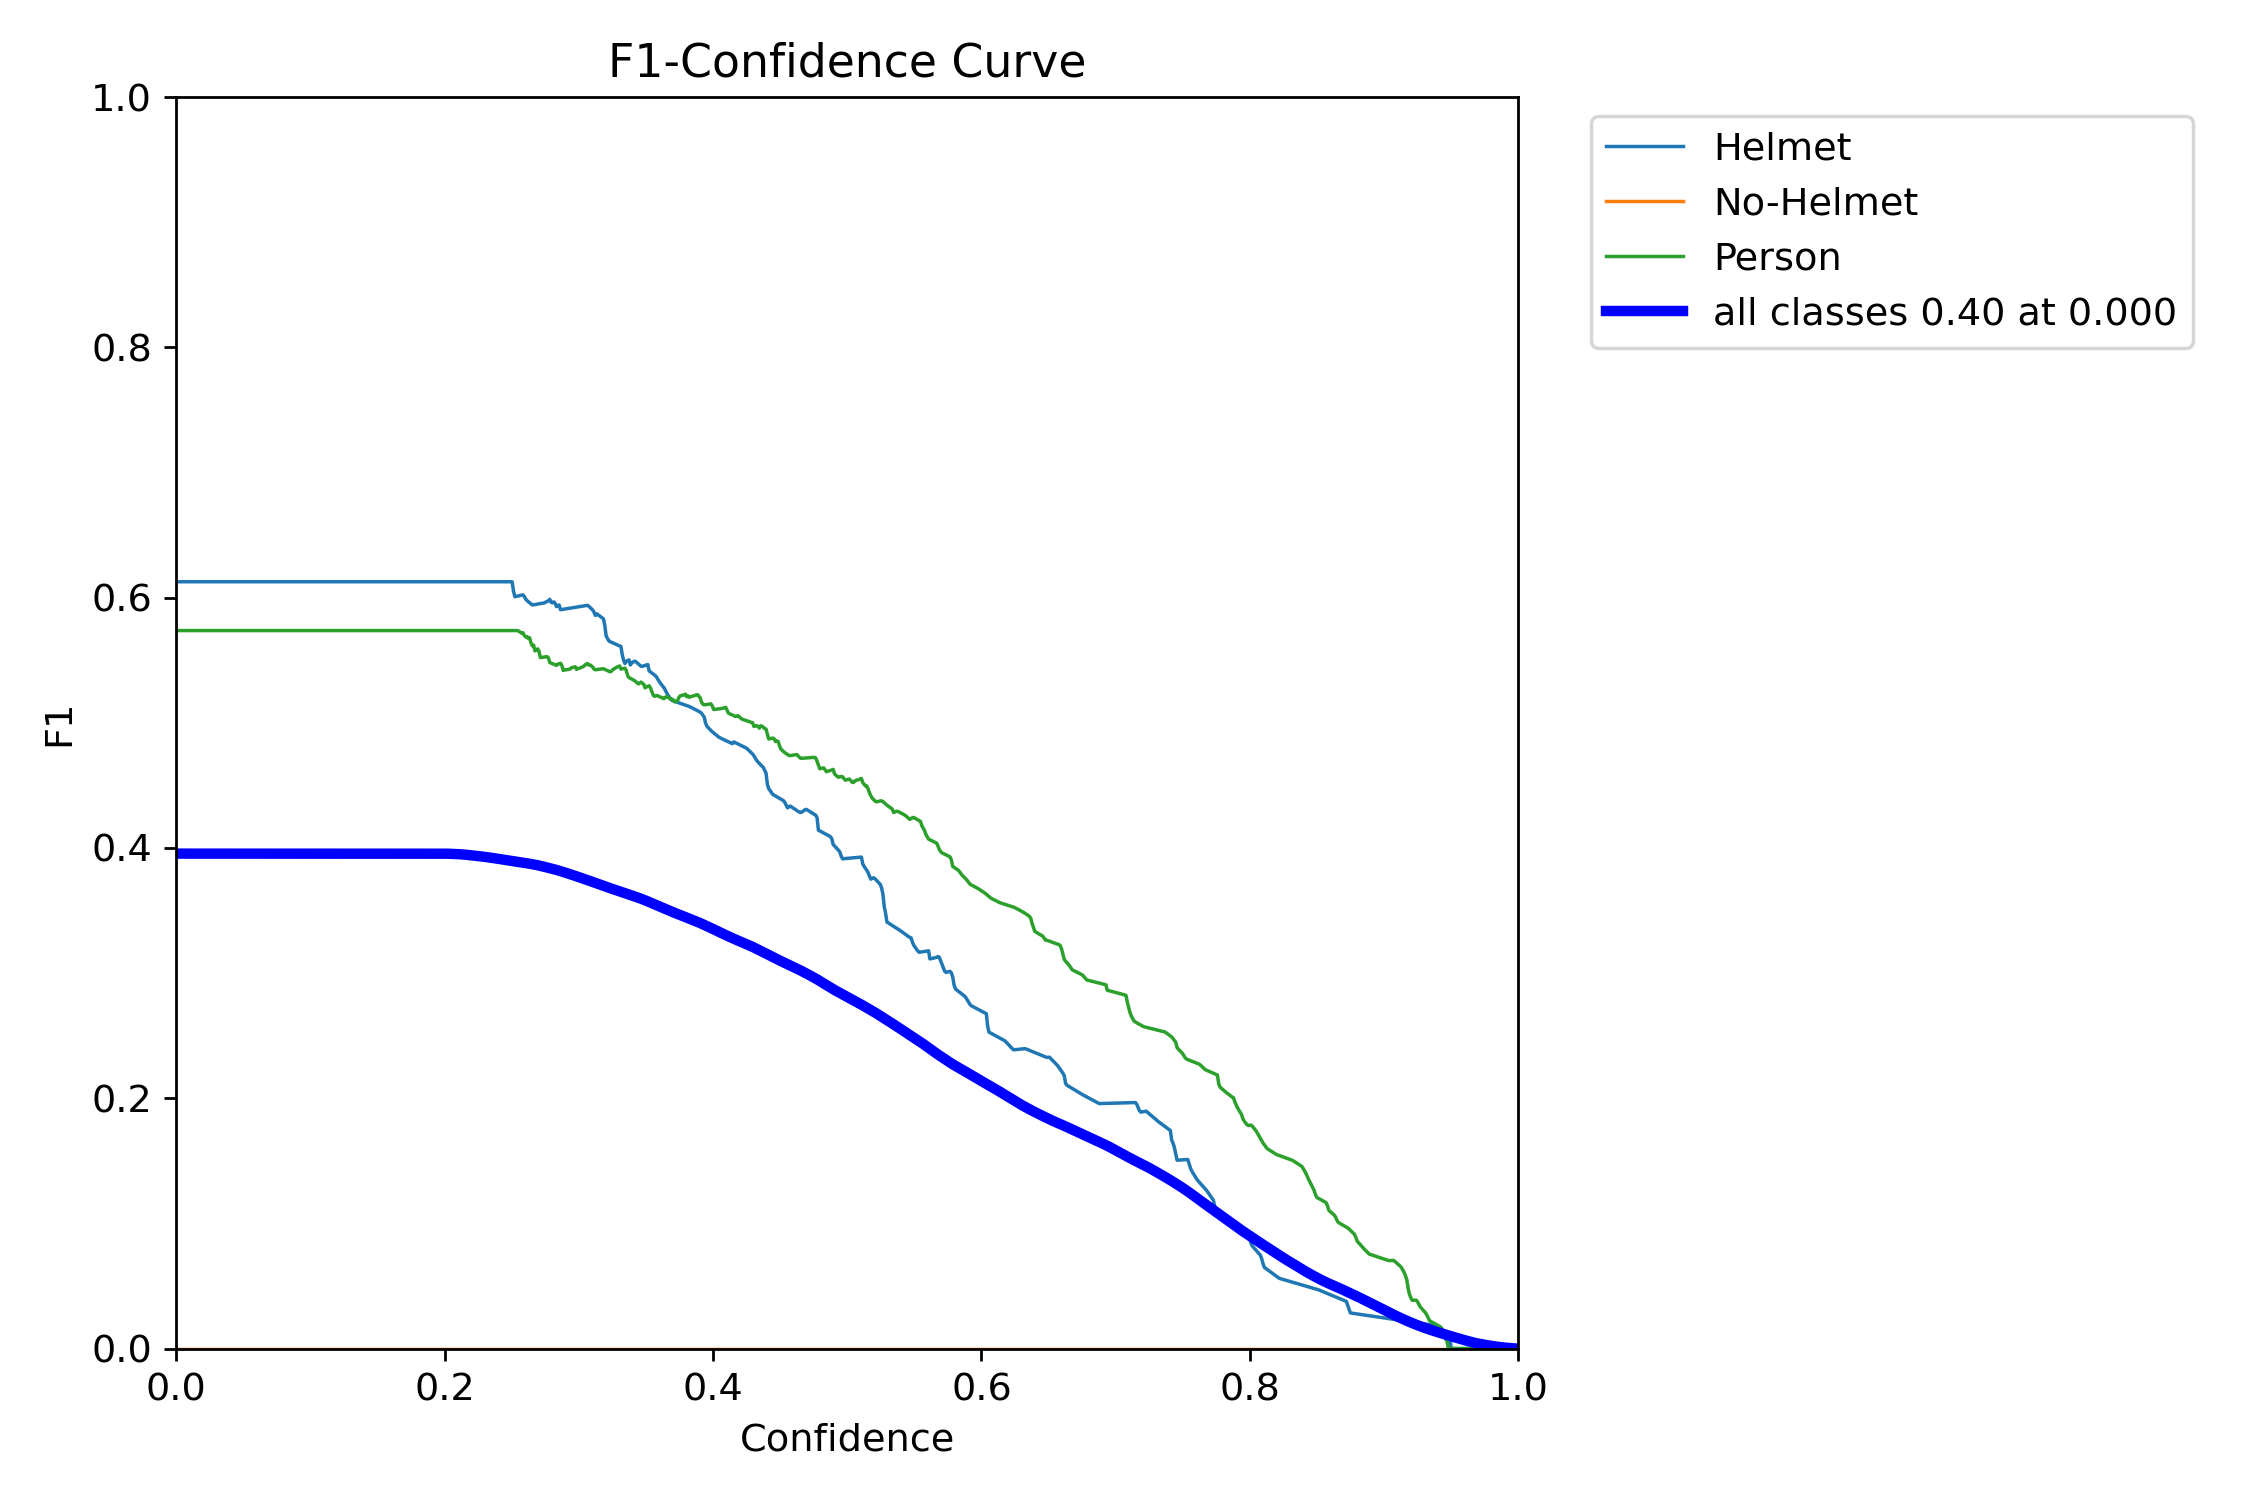

BoxP_curve.png


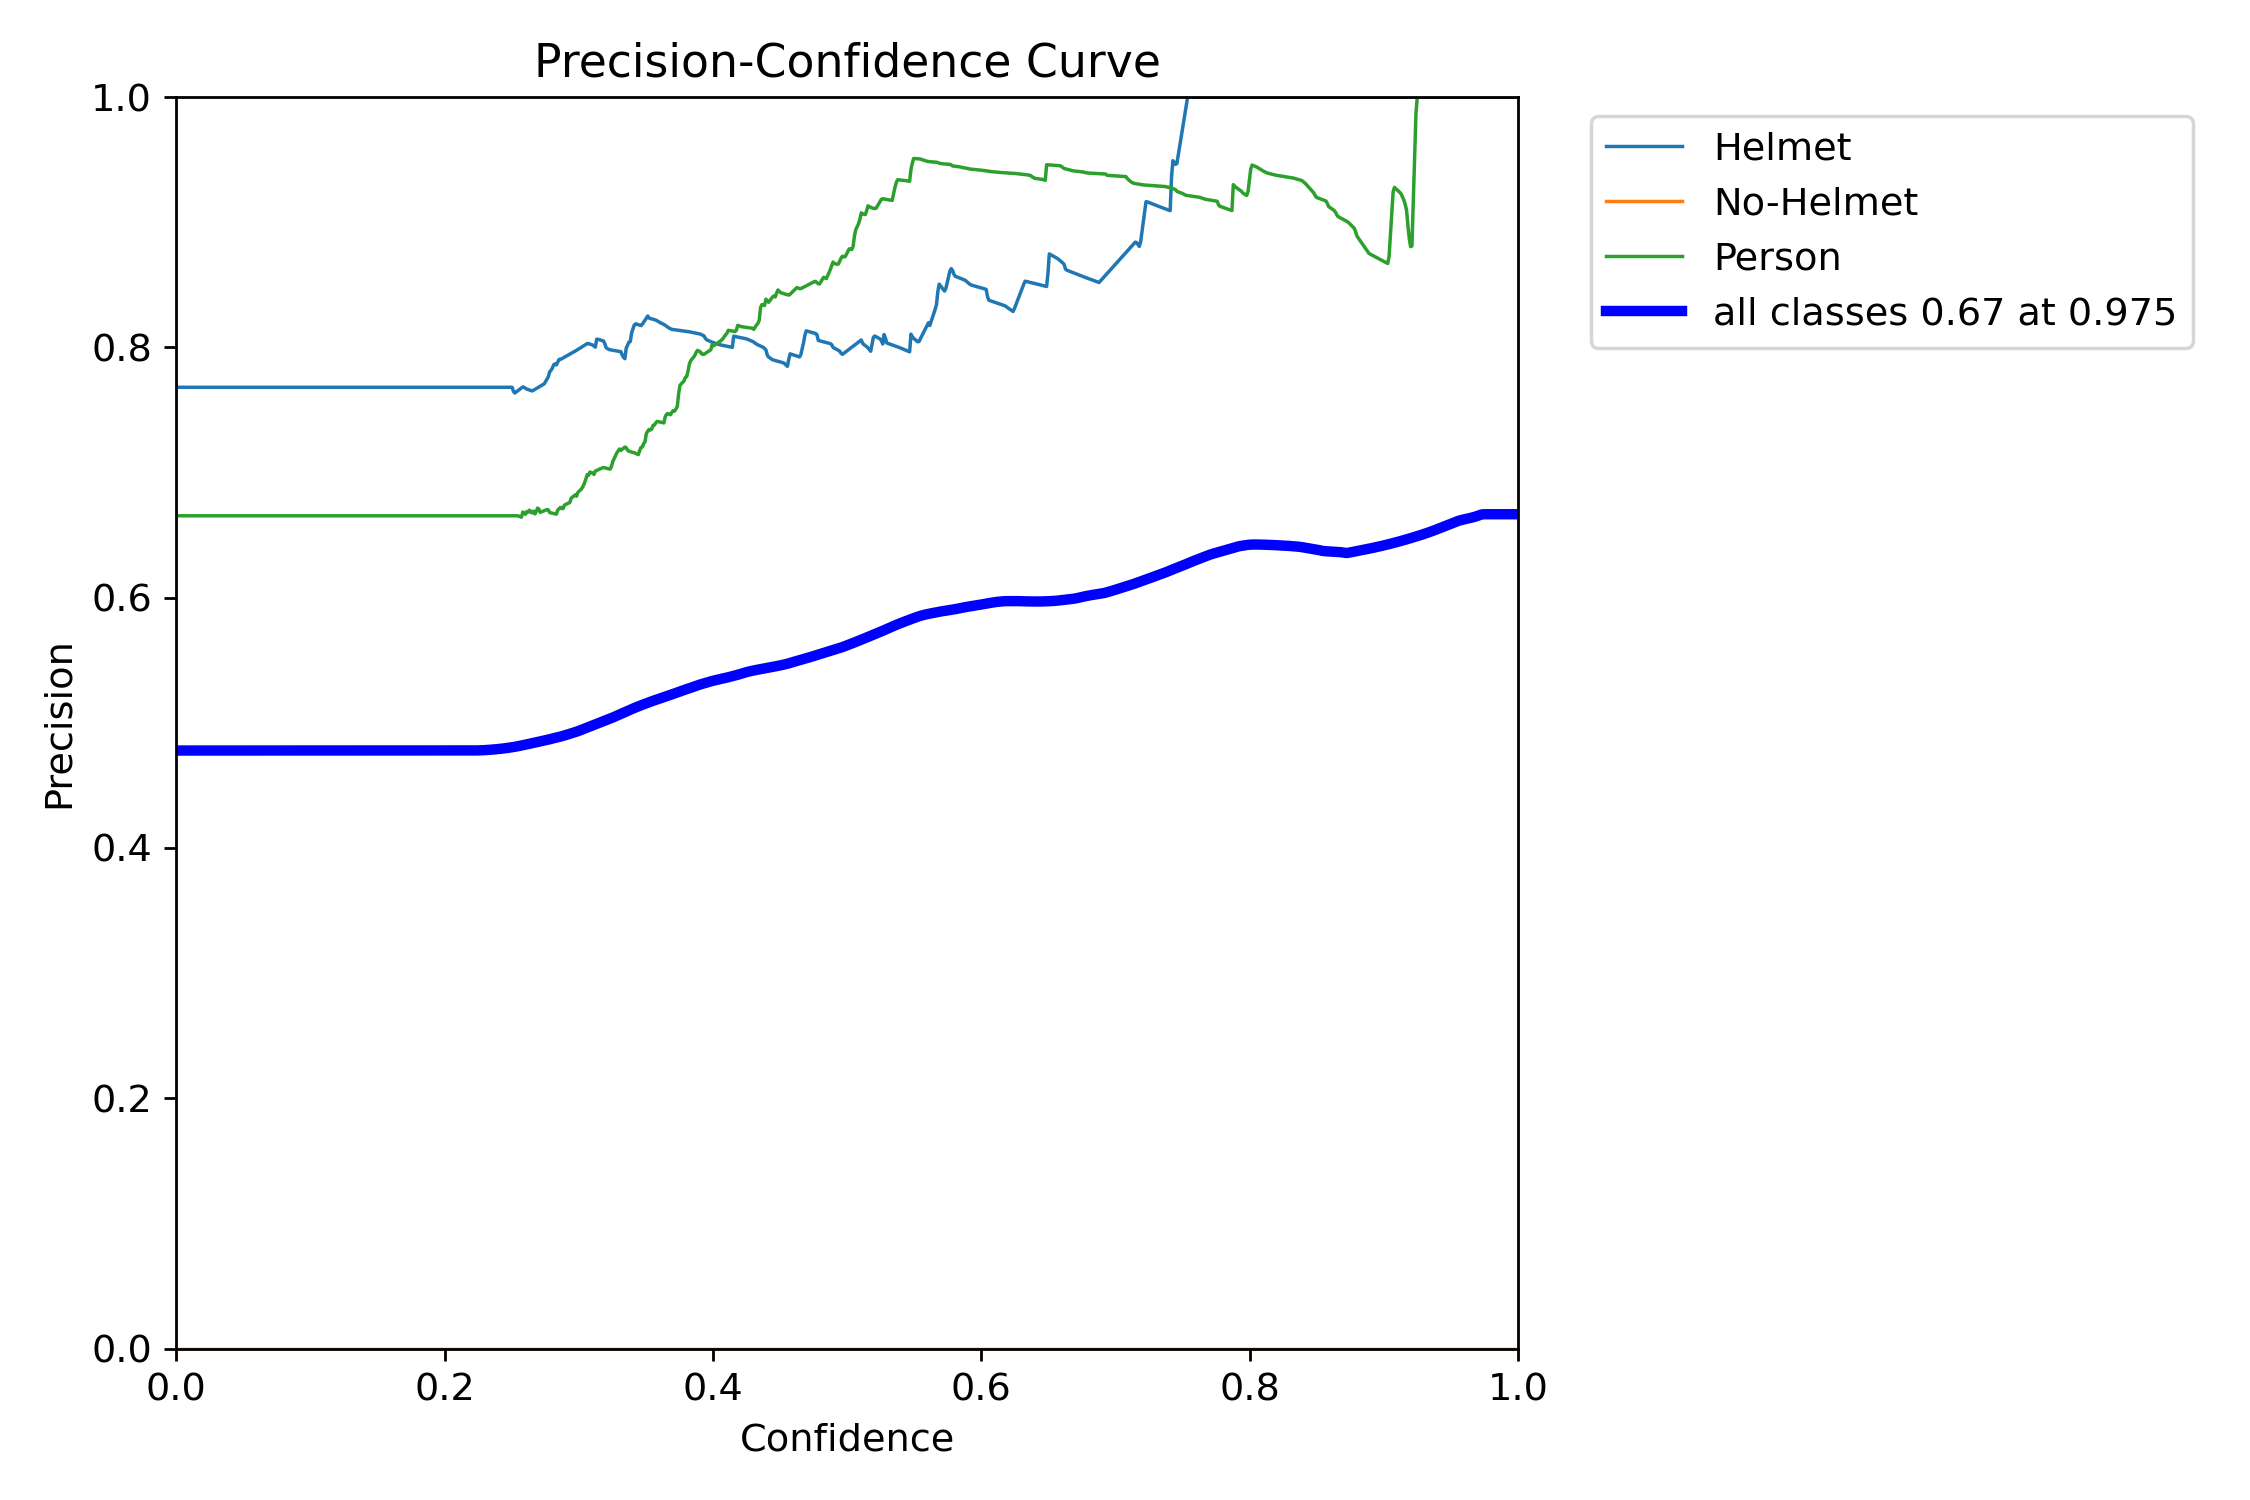

BoxPR_curve.png


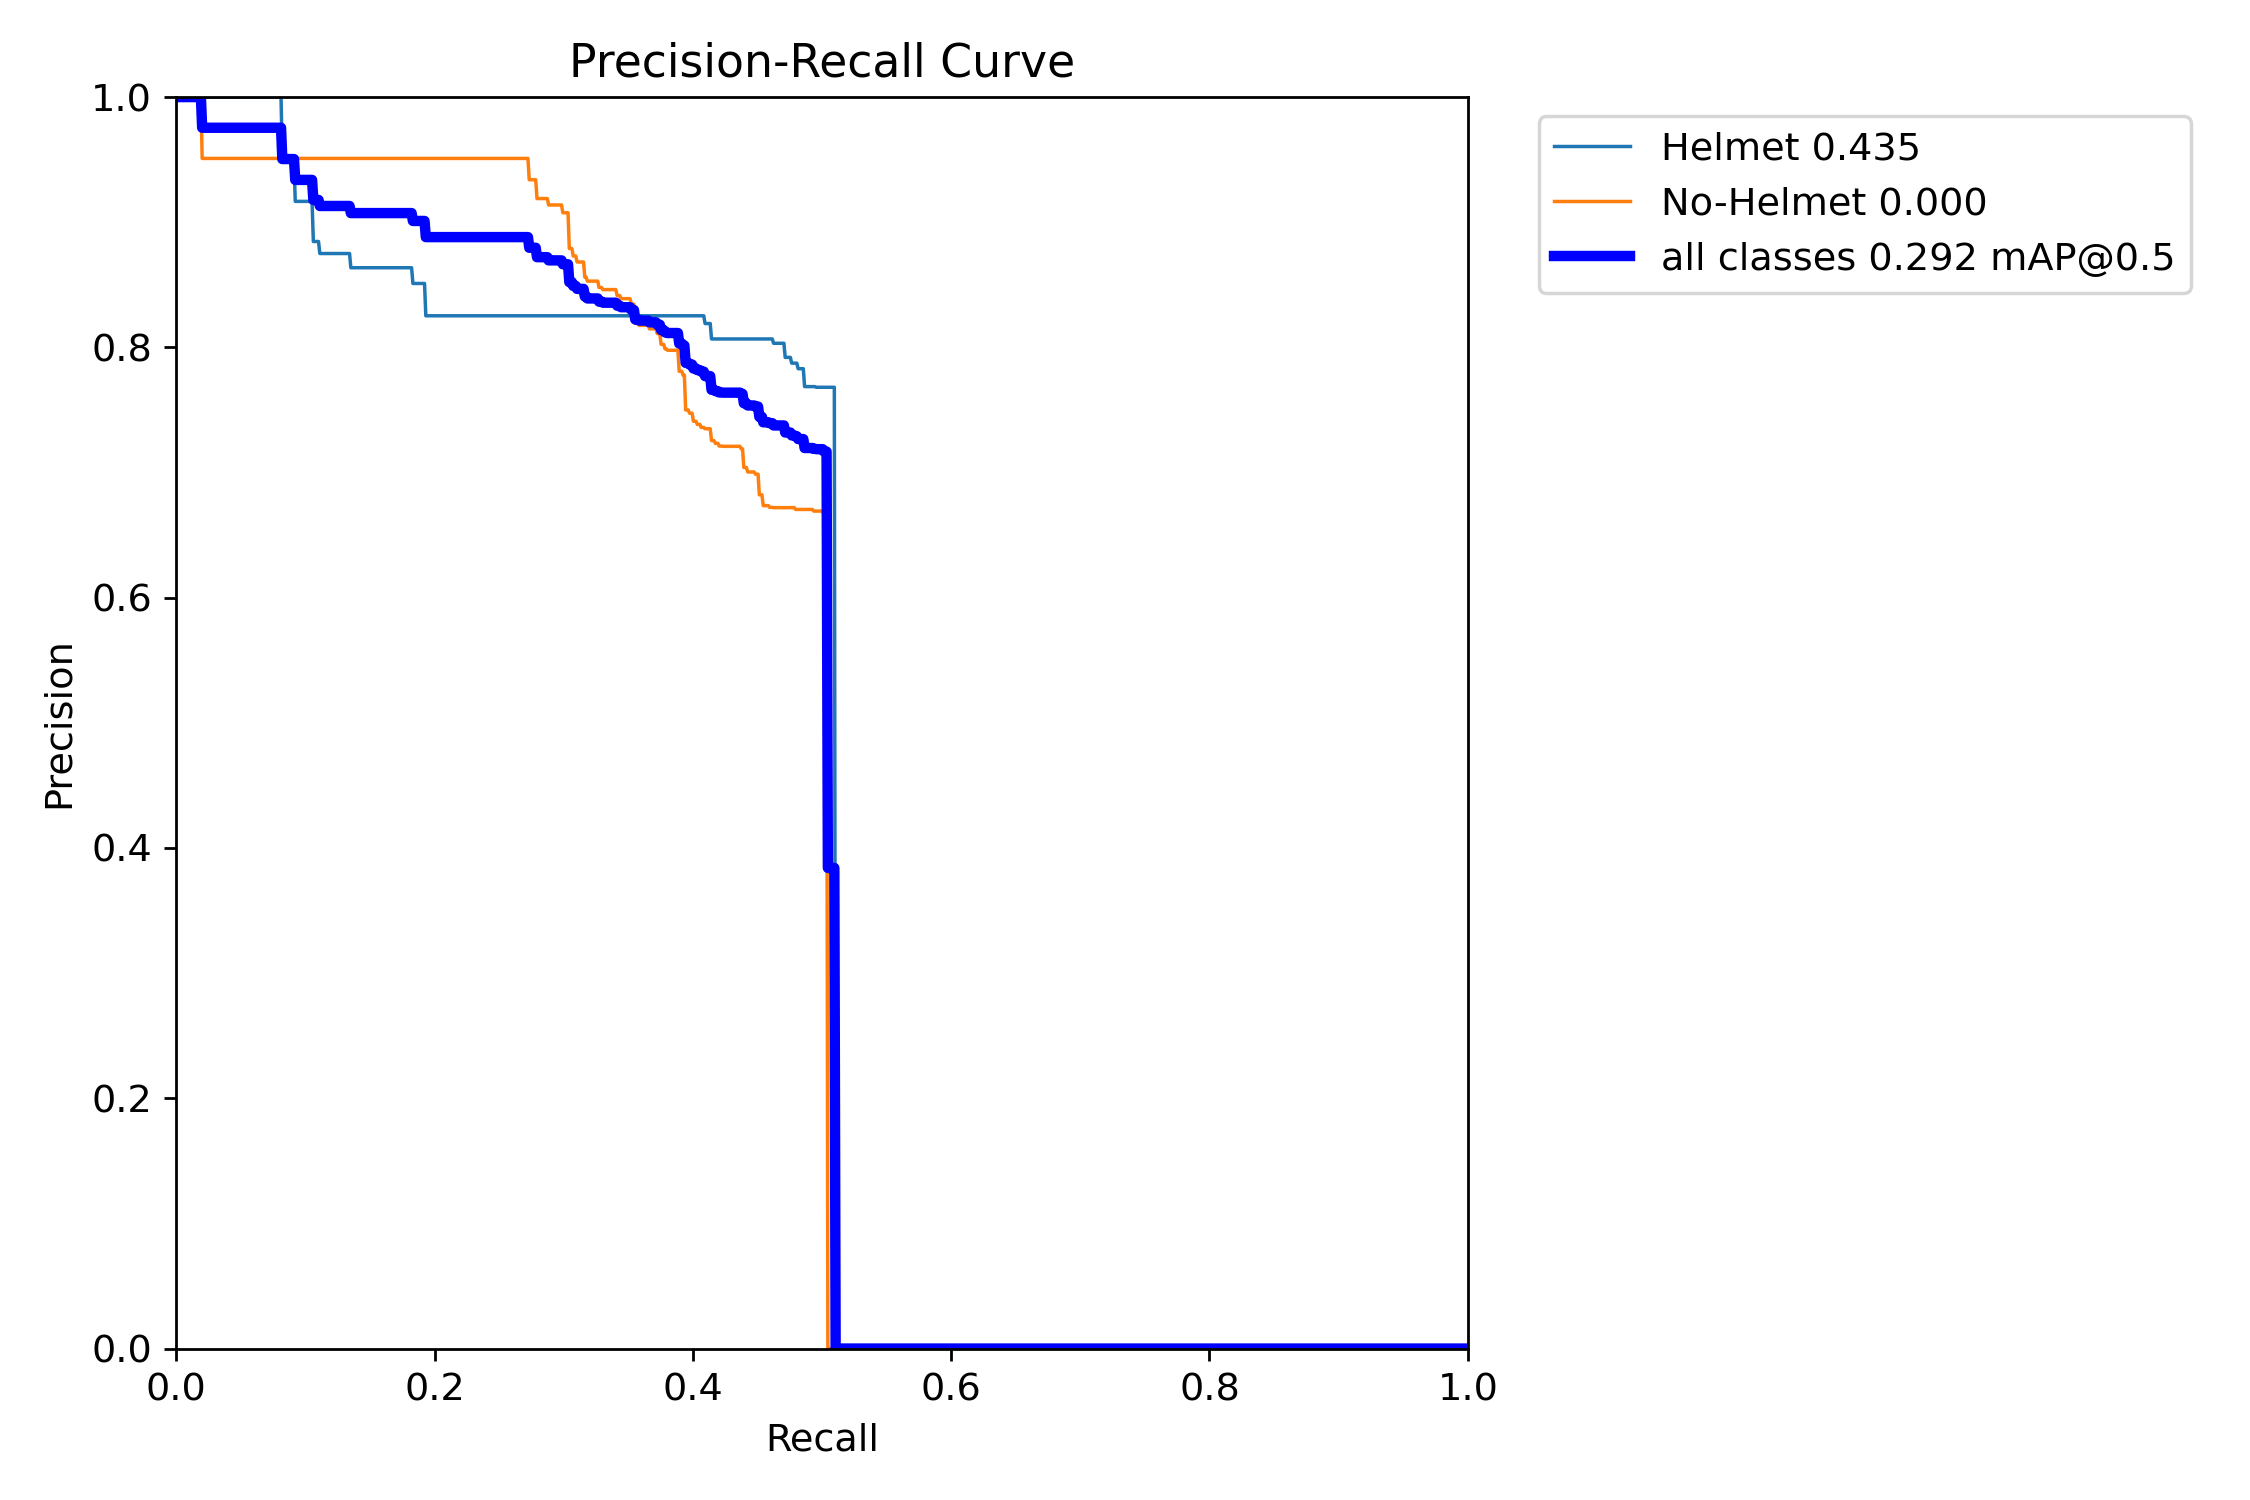

BoxR_curve.png


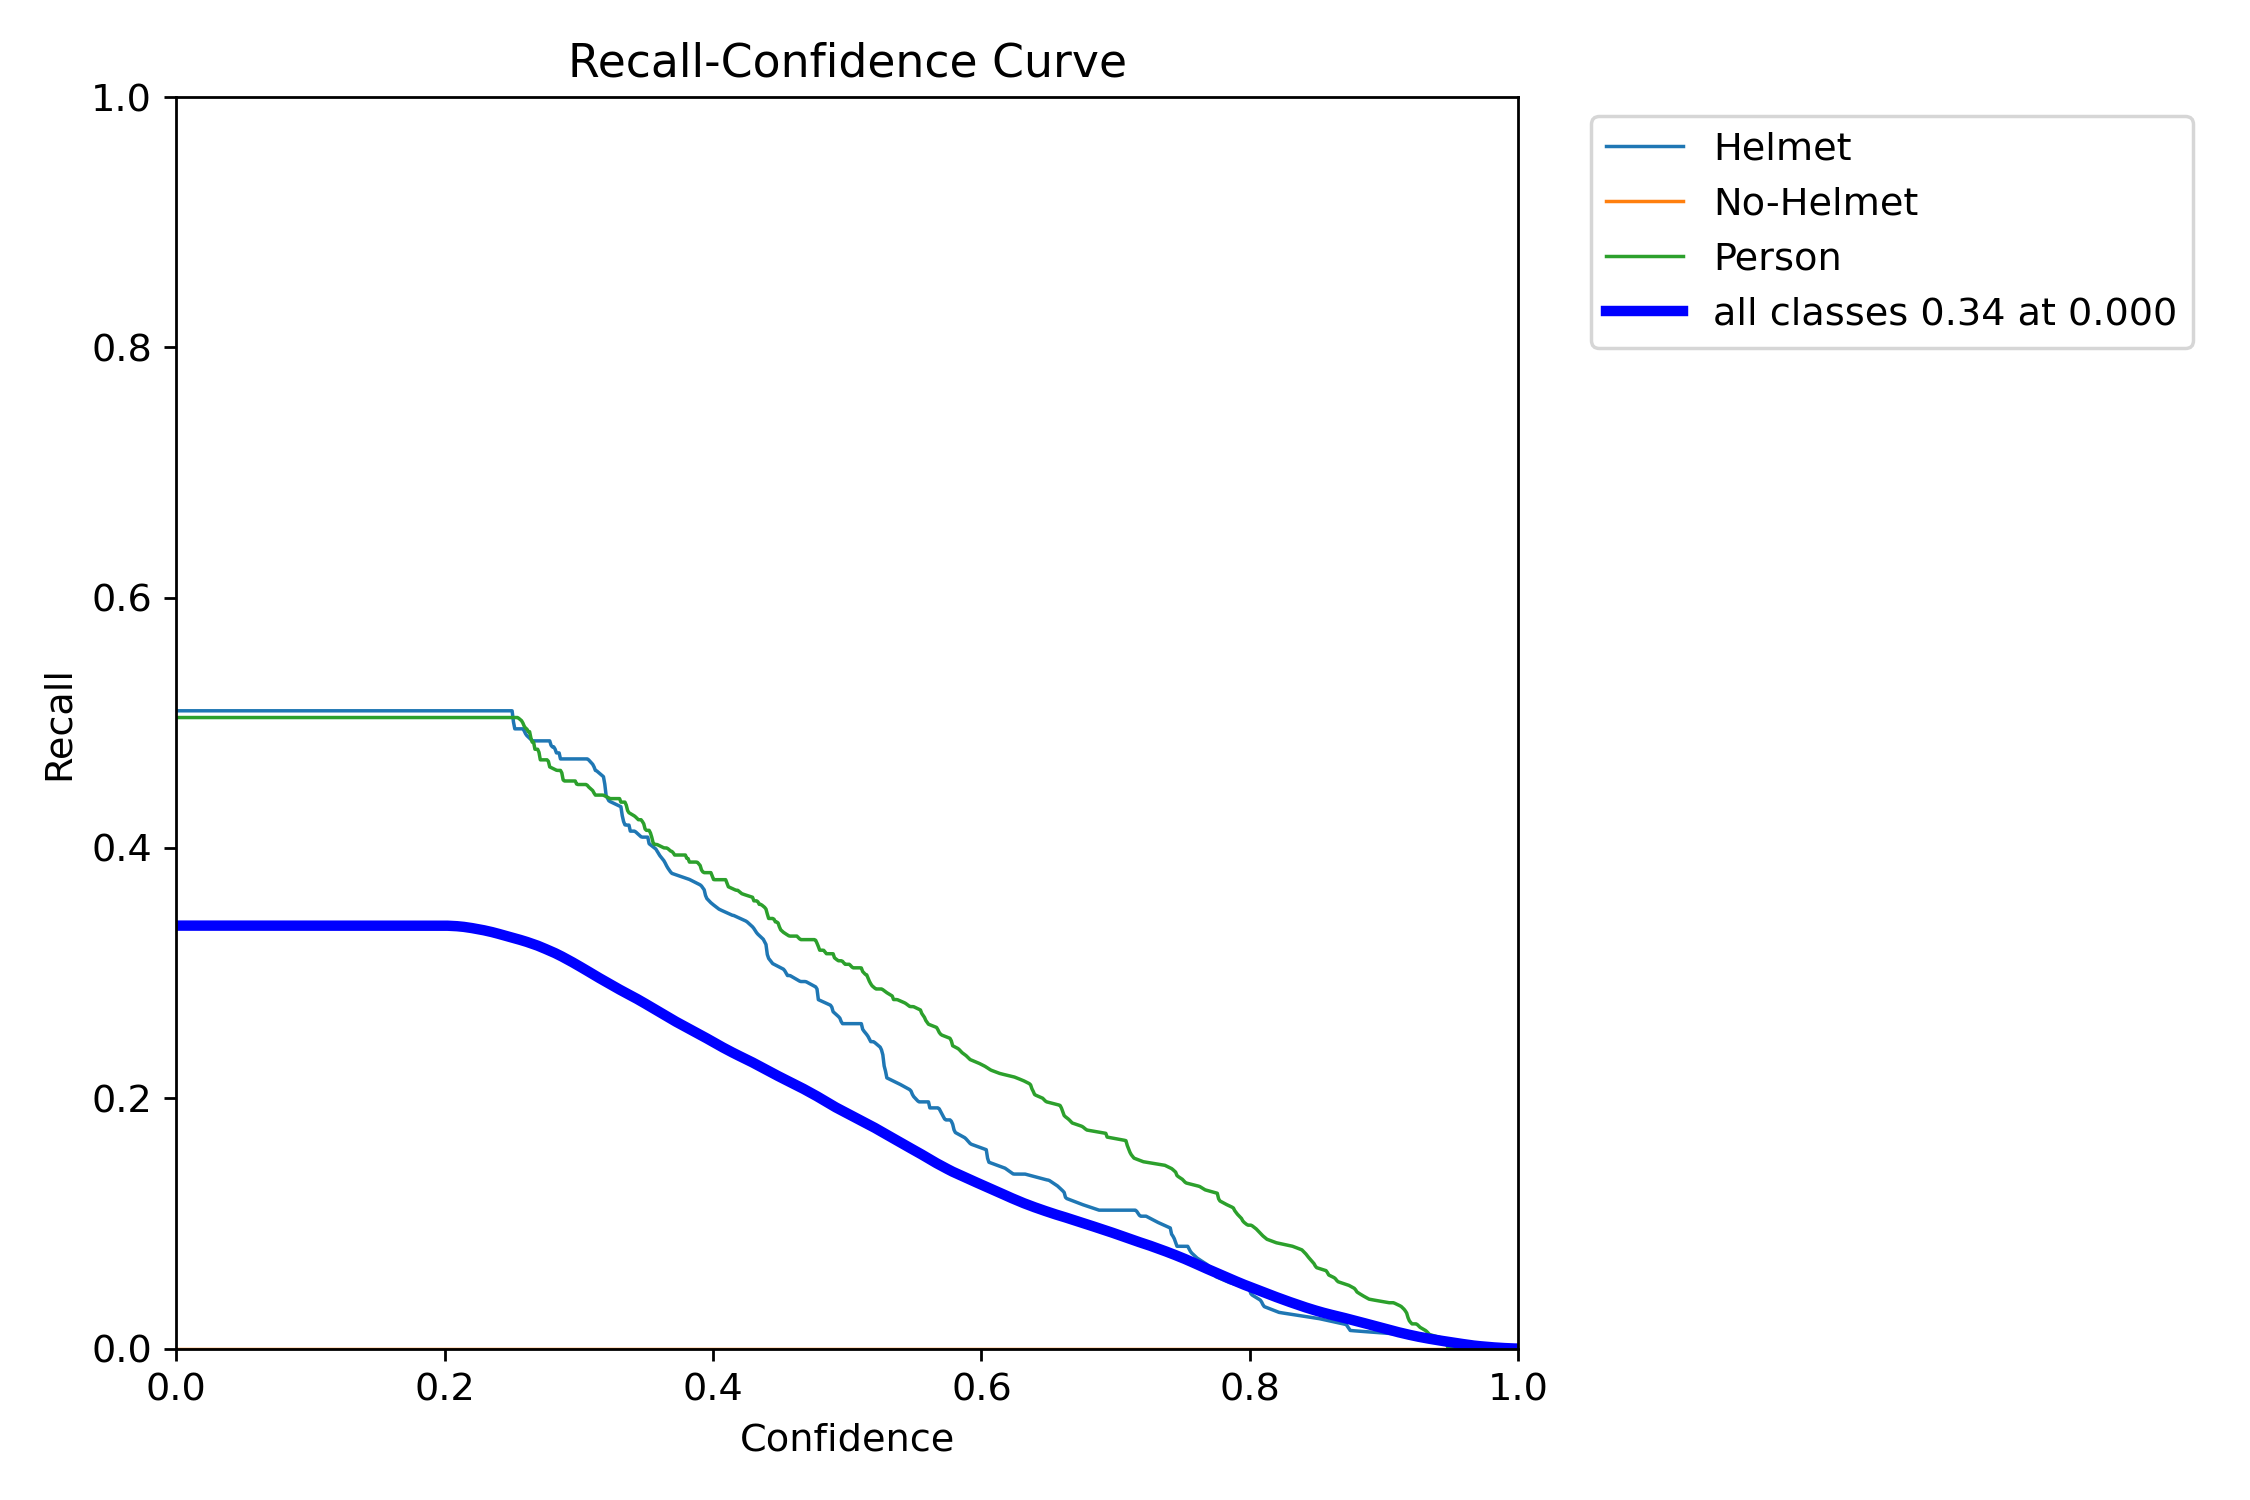

confusion_matrix.png


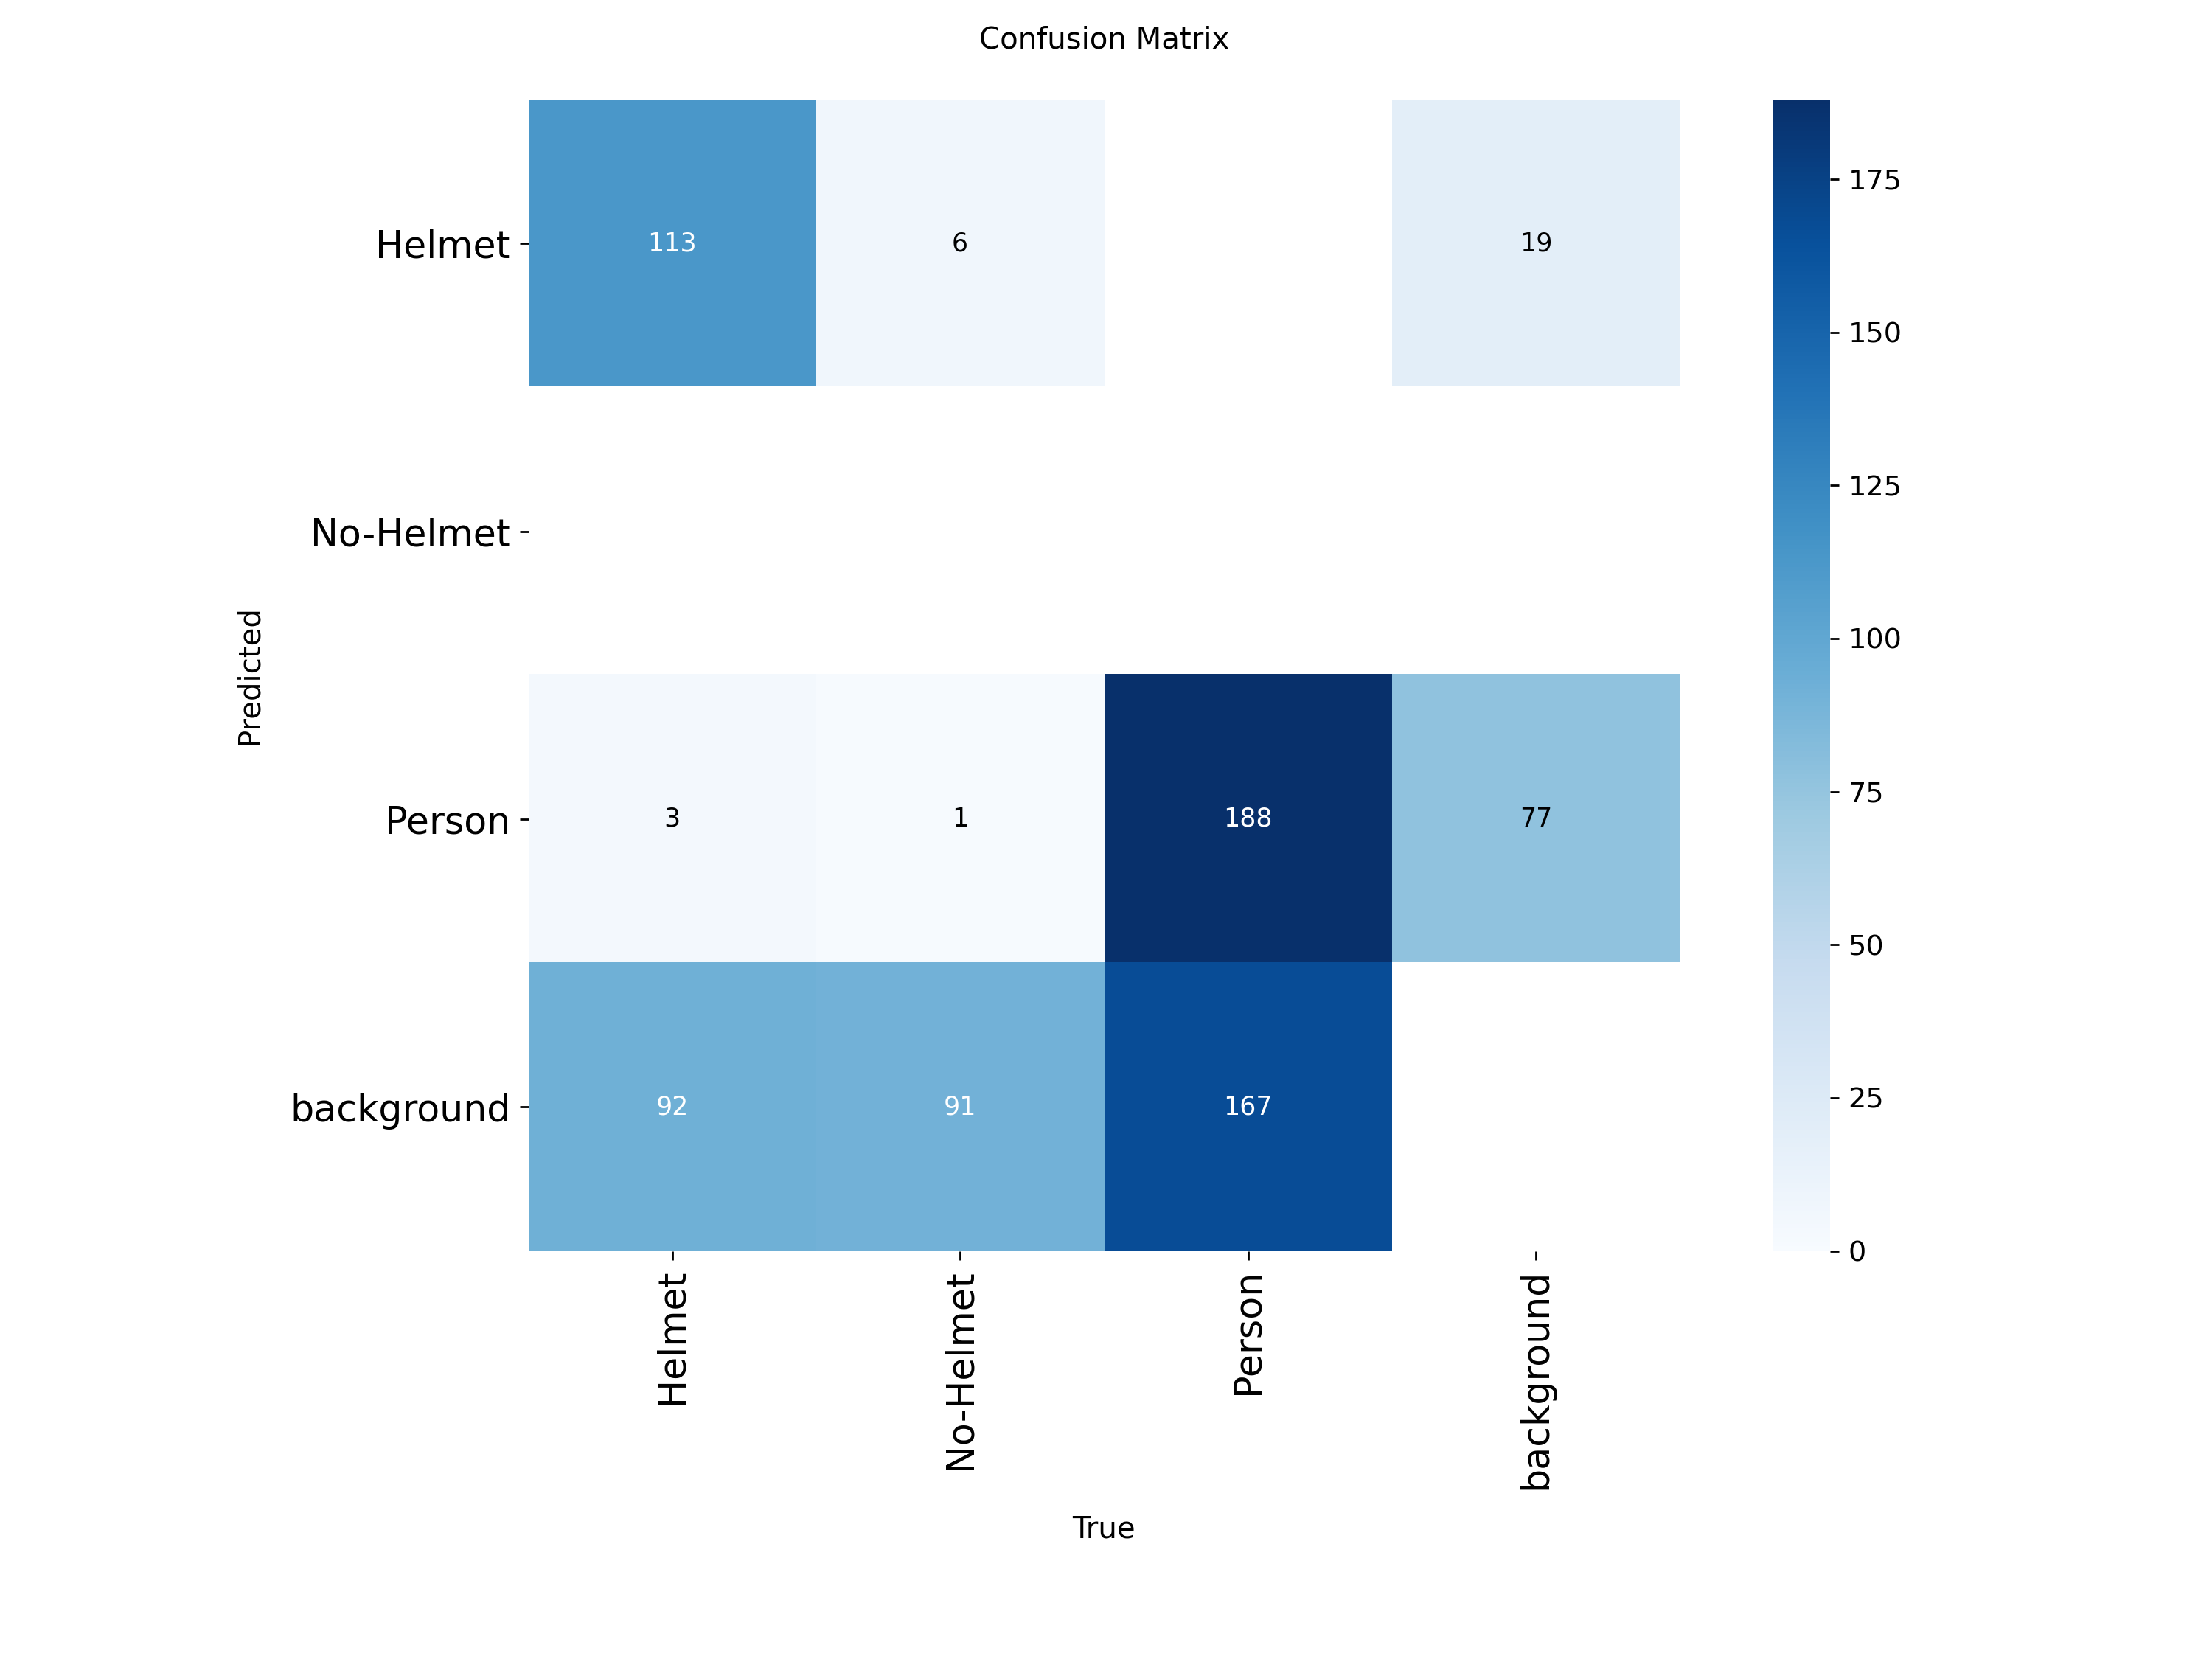

confusion_matrix_normalized.png


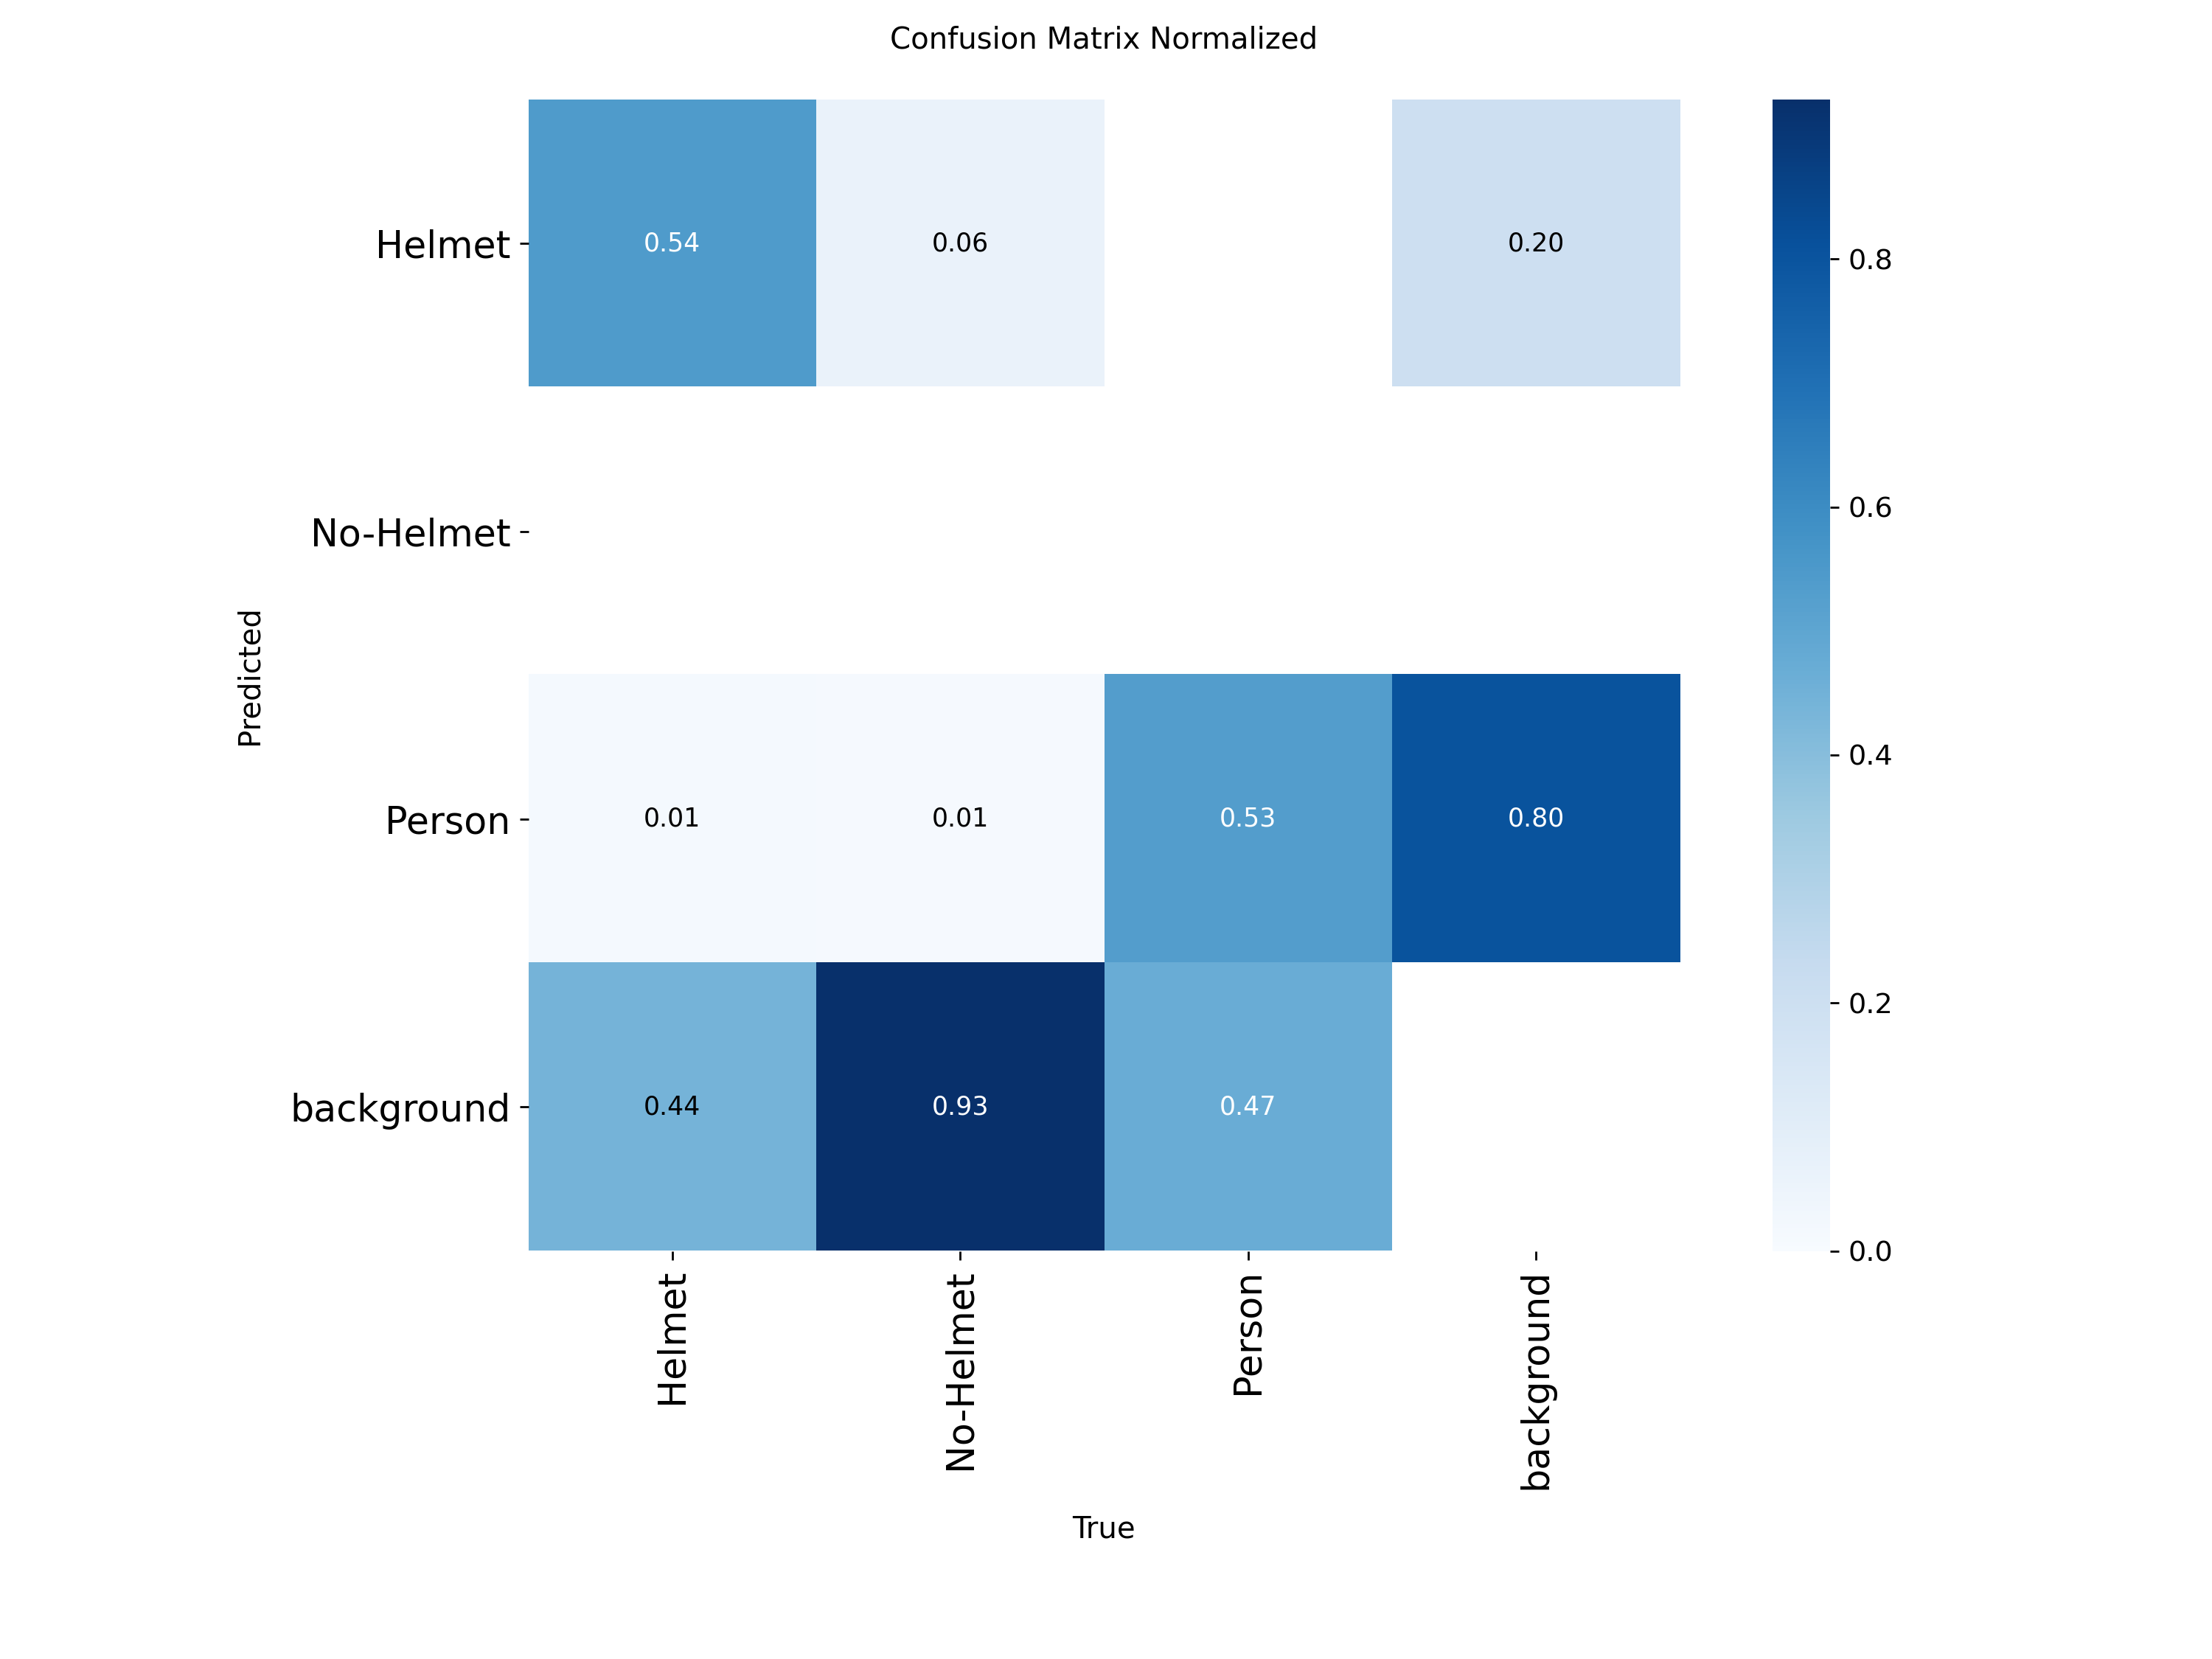

=== test ===
BoxF1_curve.png


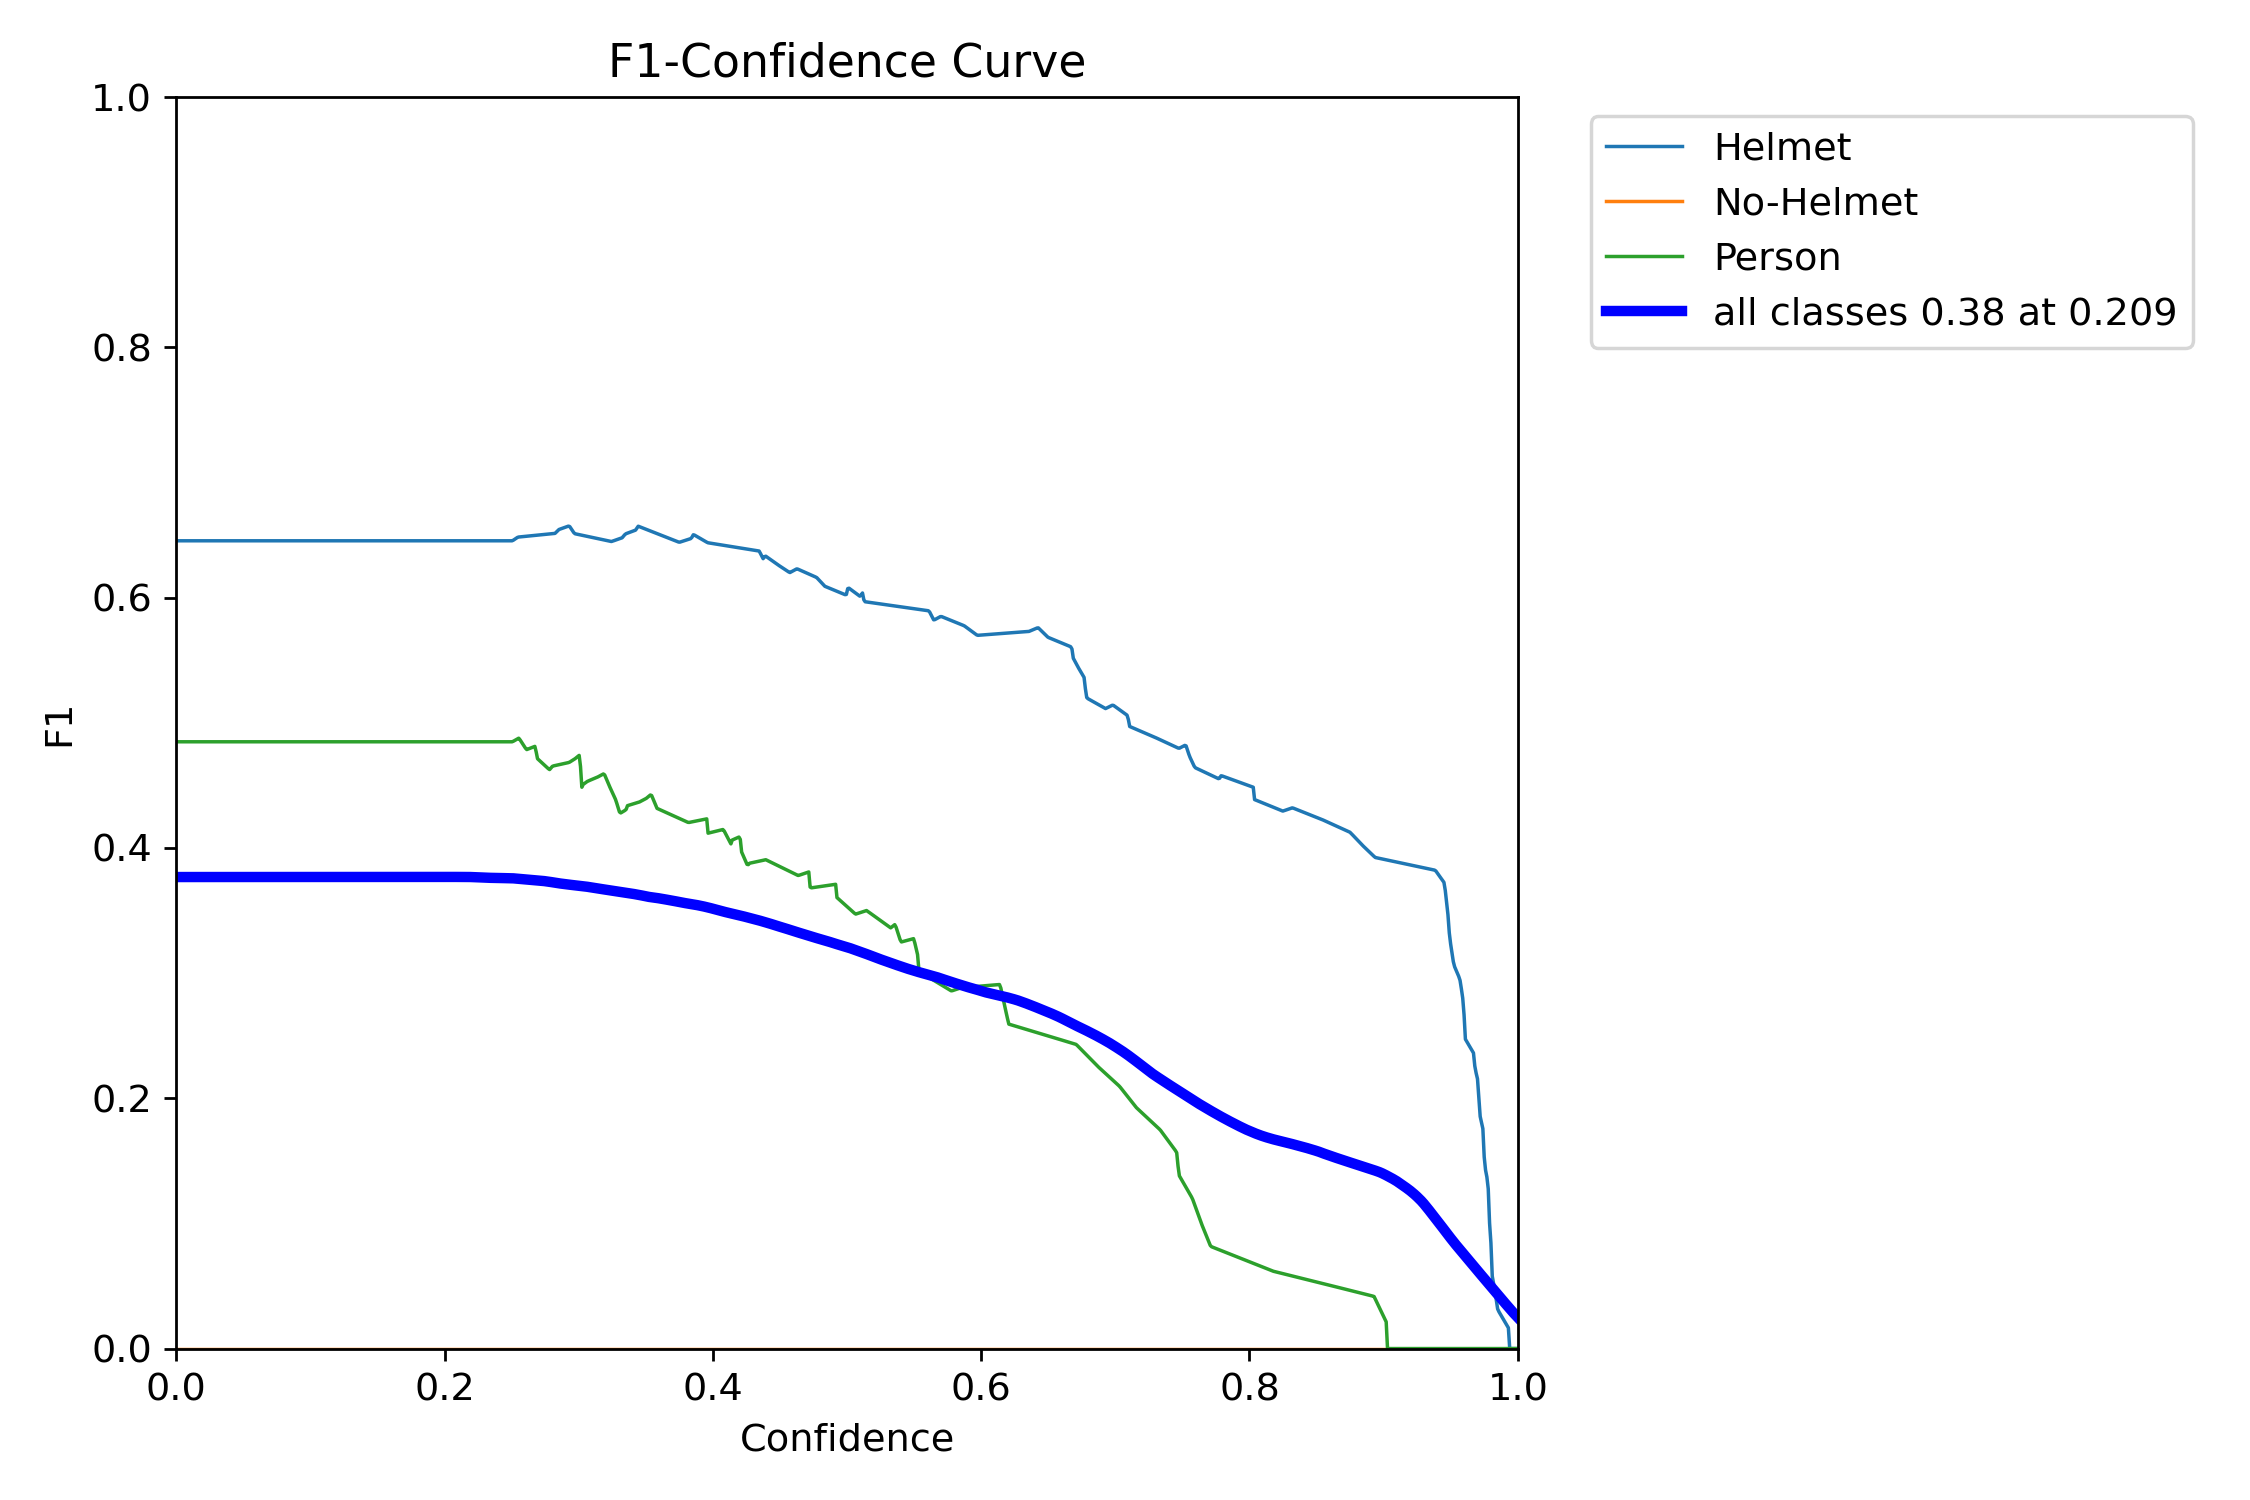

BoxP_curve.png


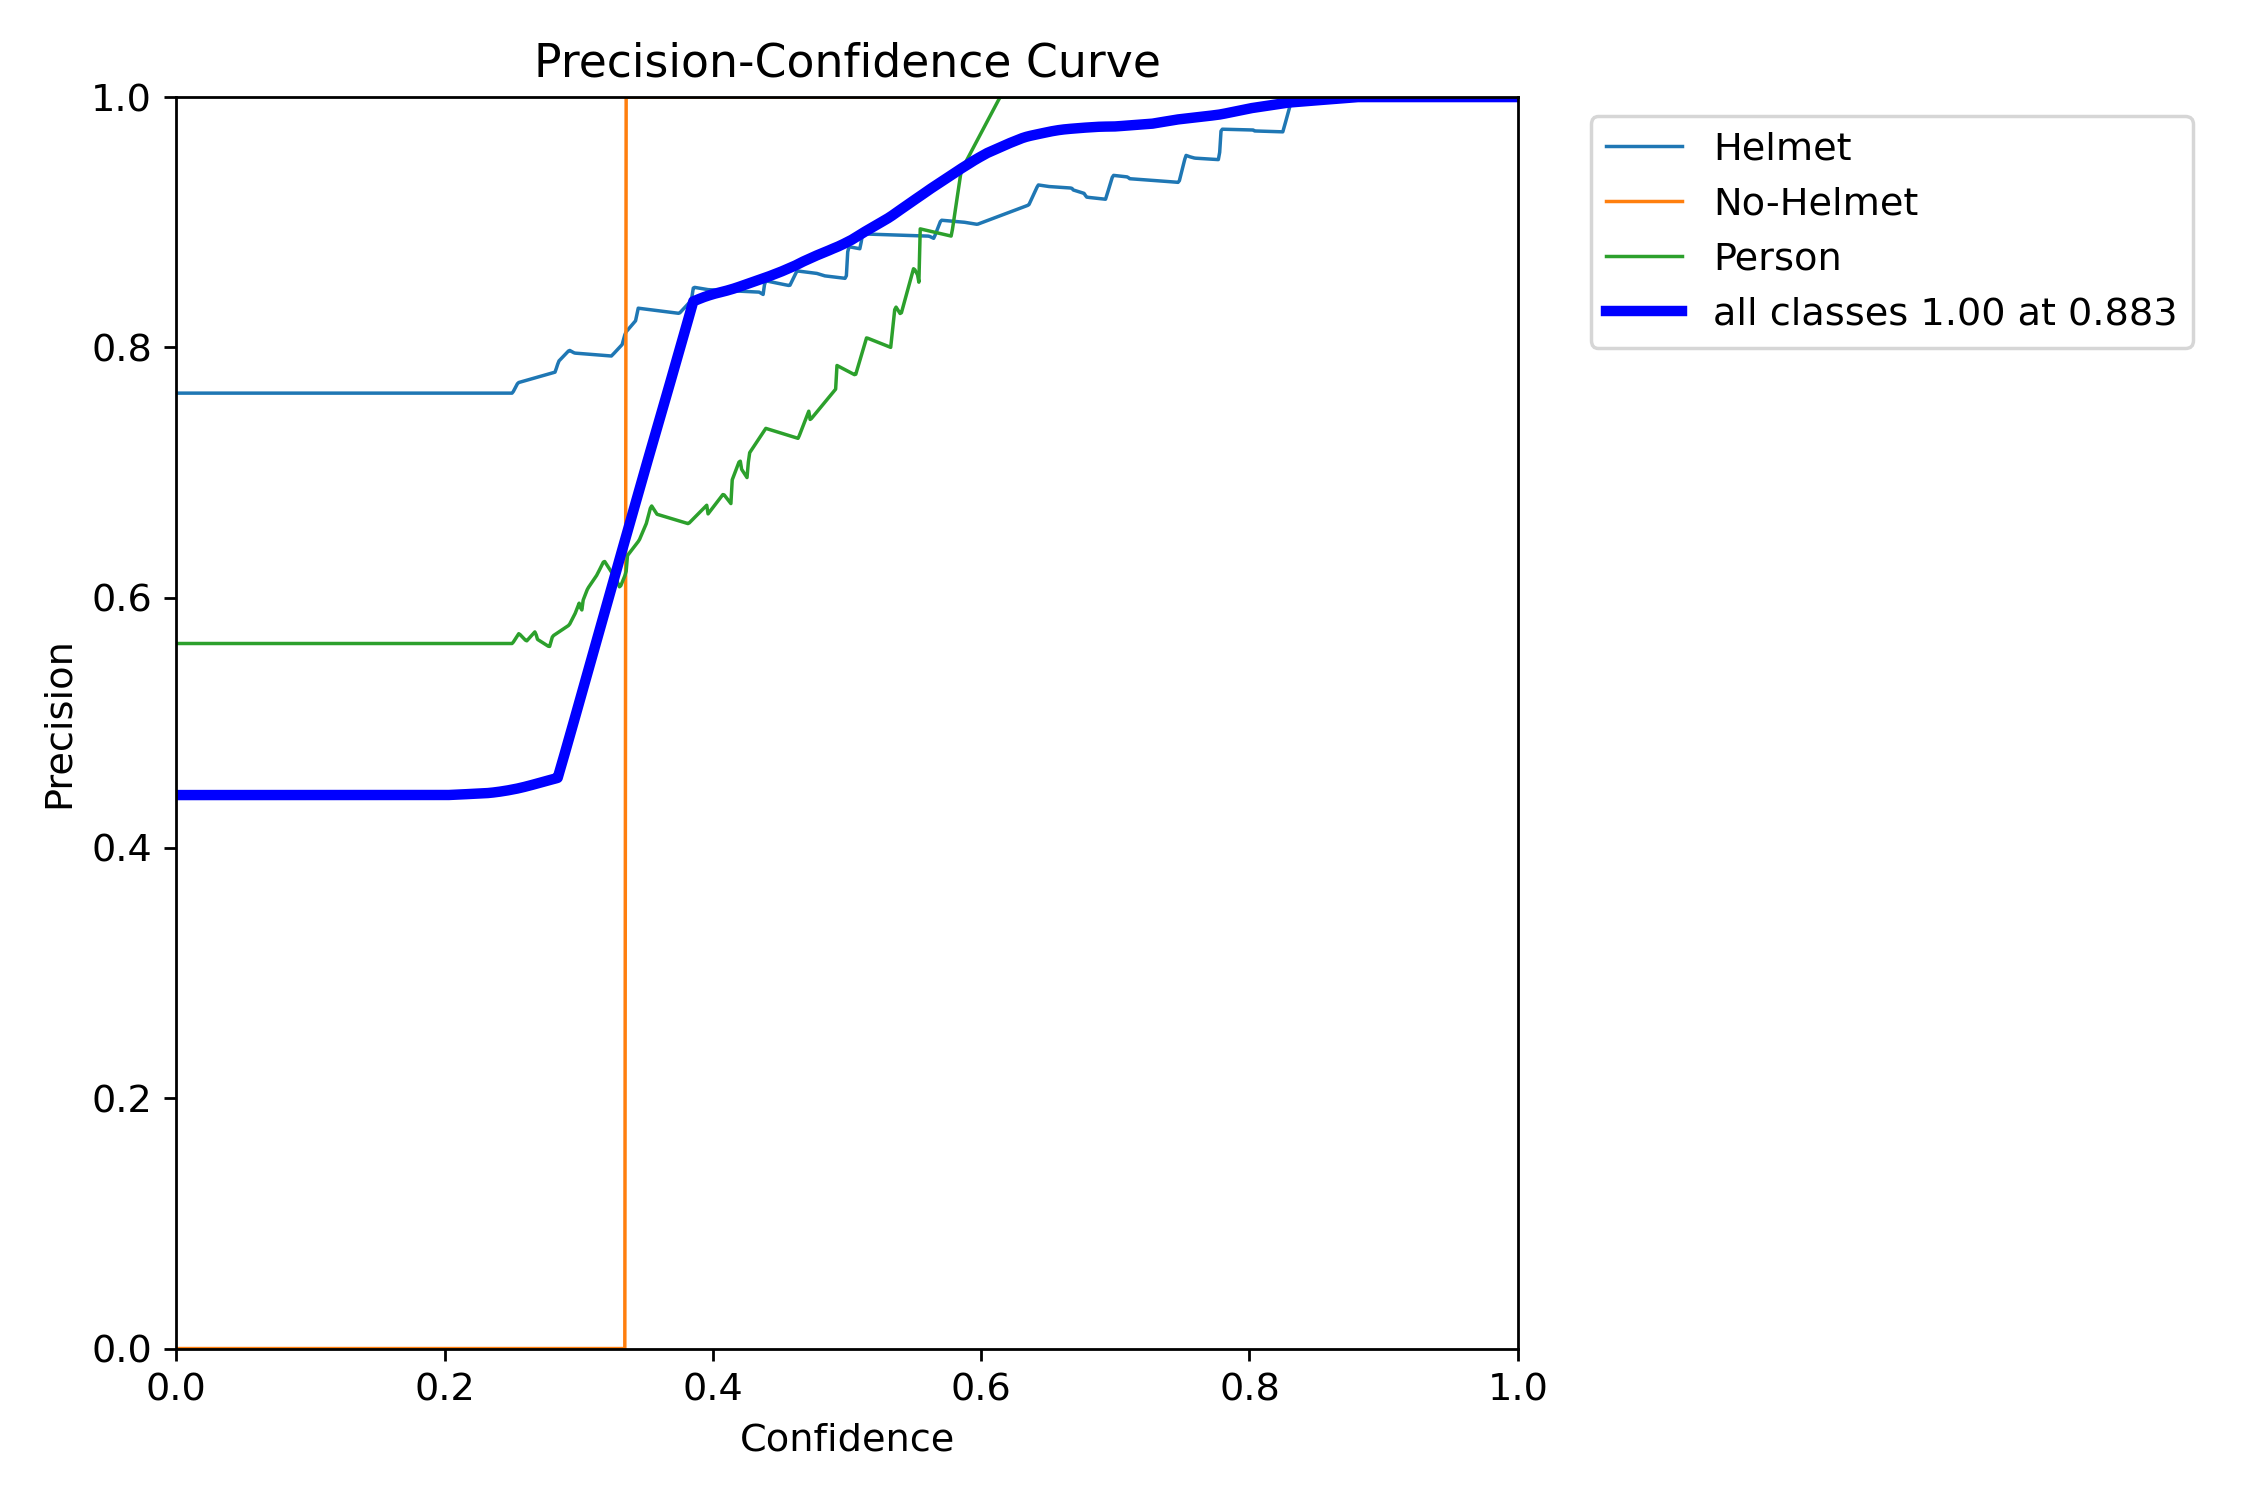

BoxPR_curve.png


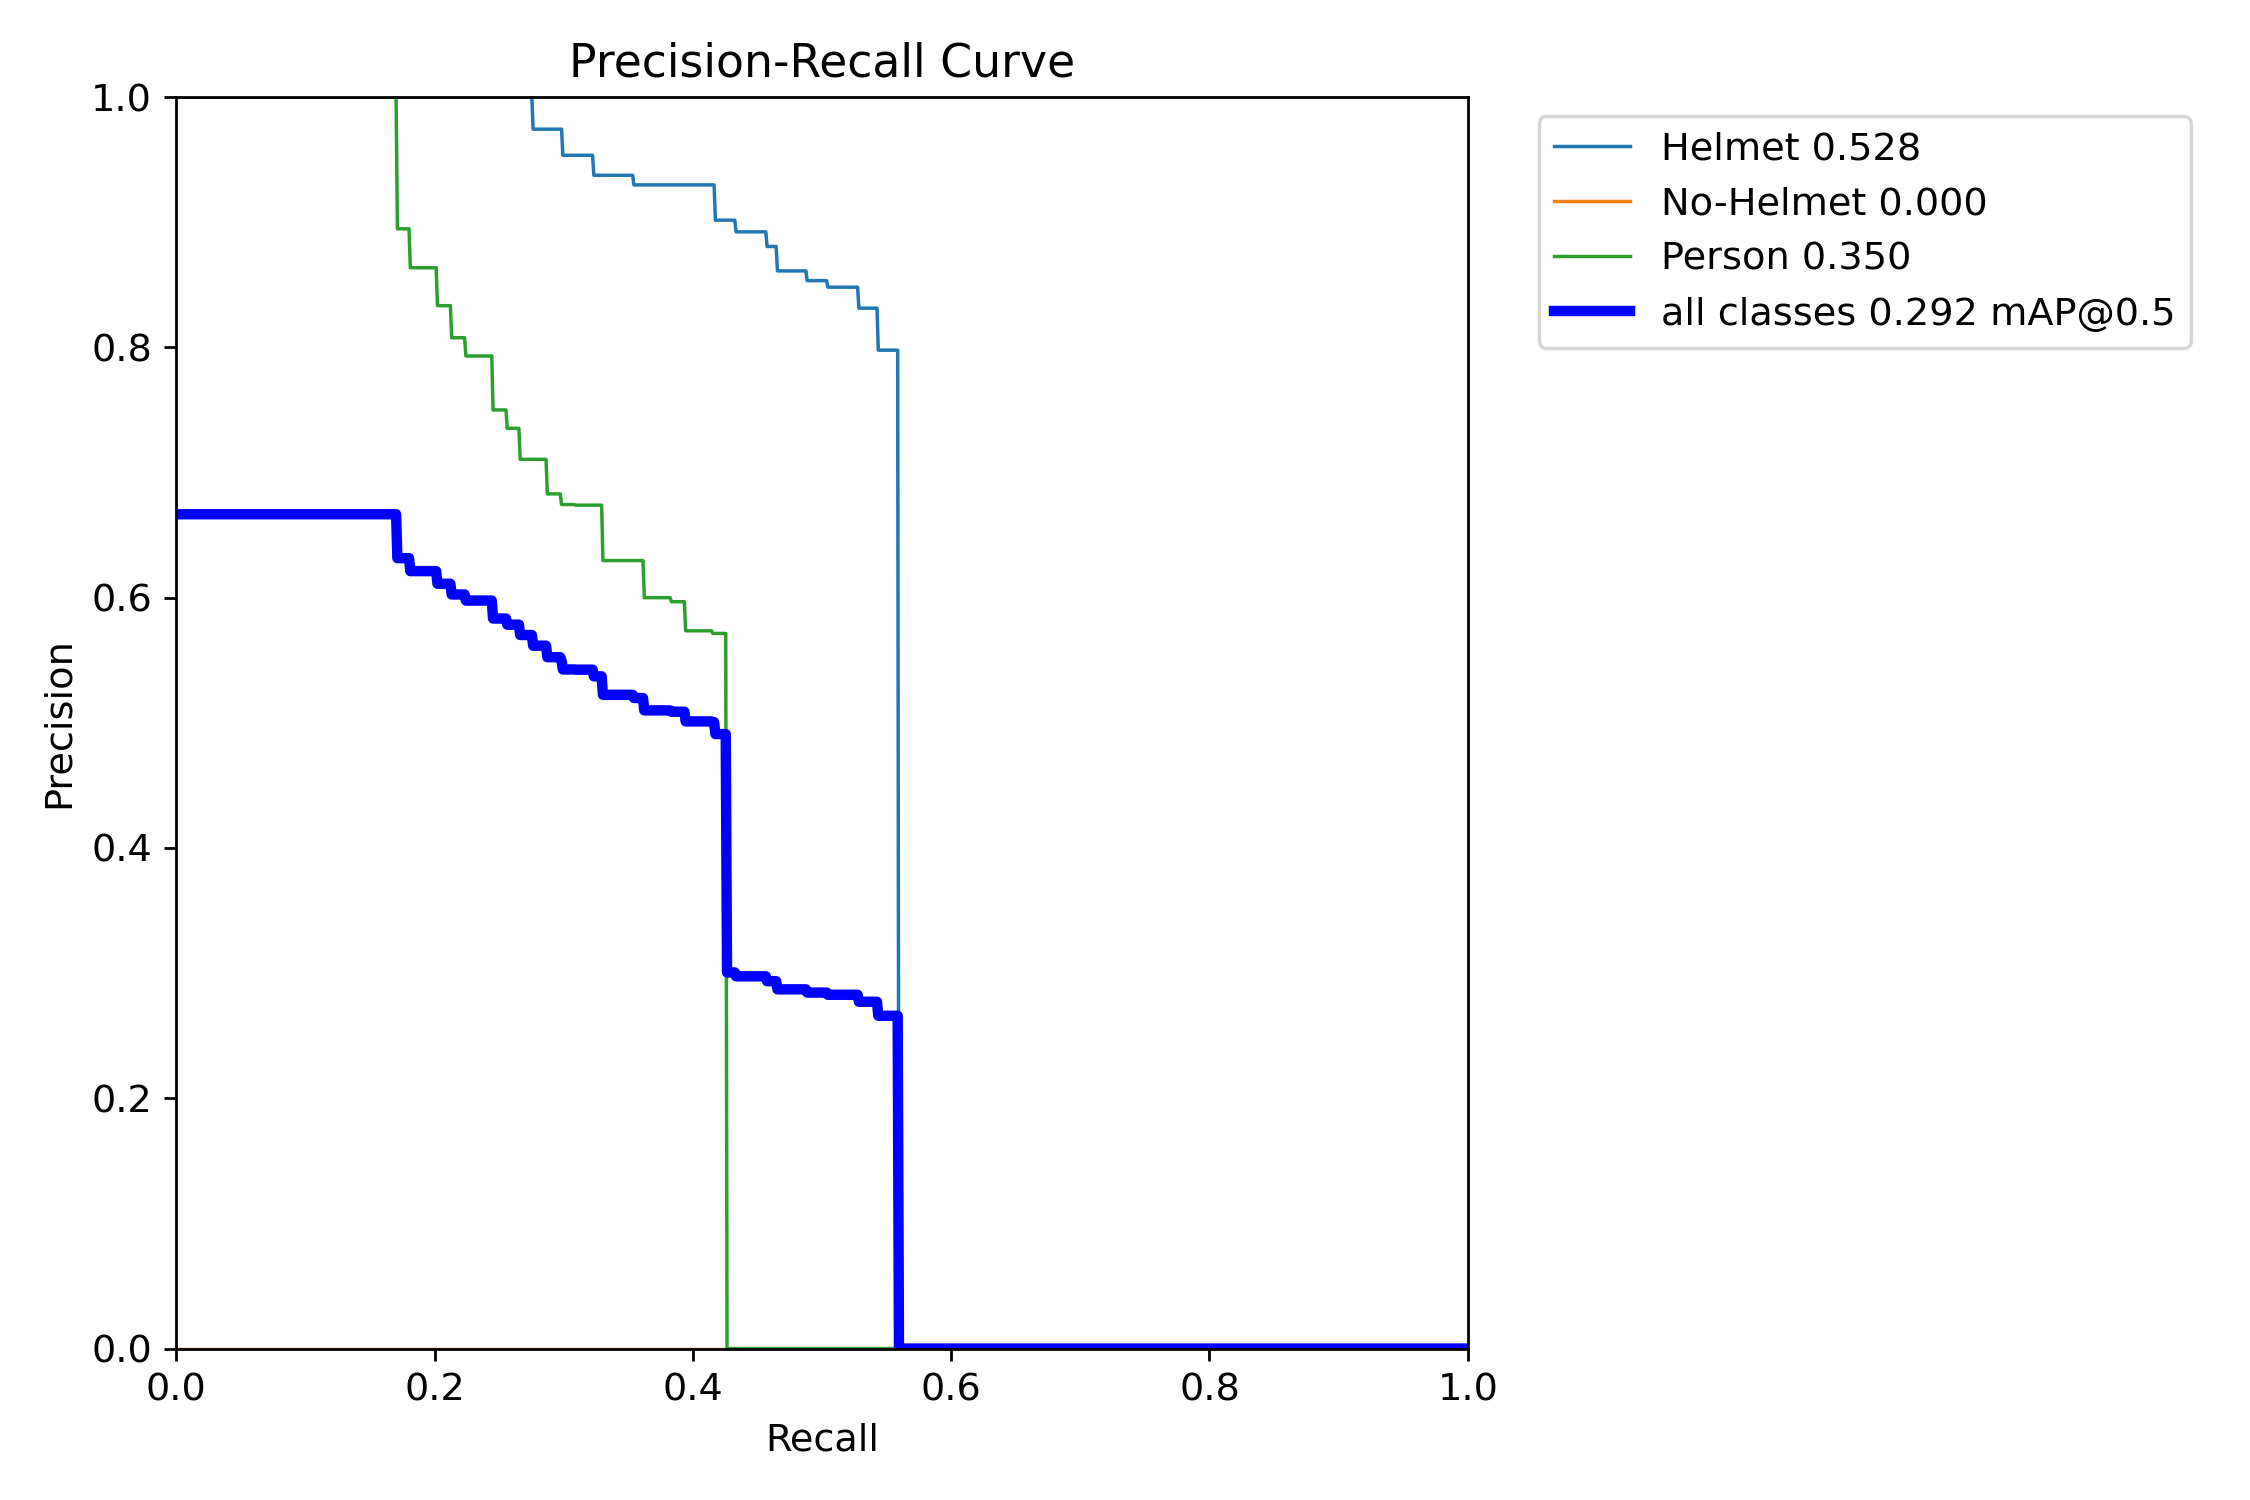

BoxR_curve.png


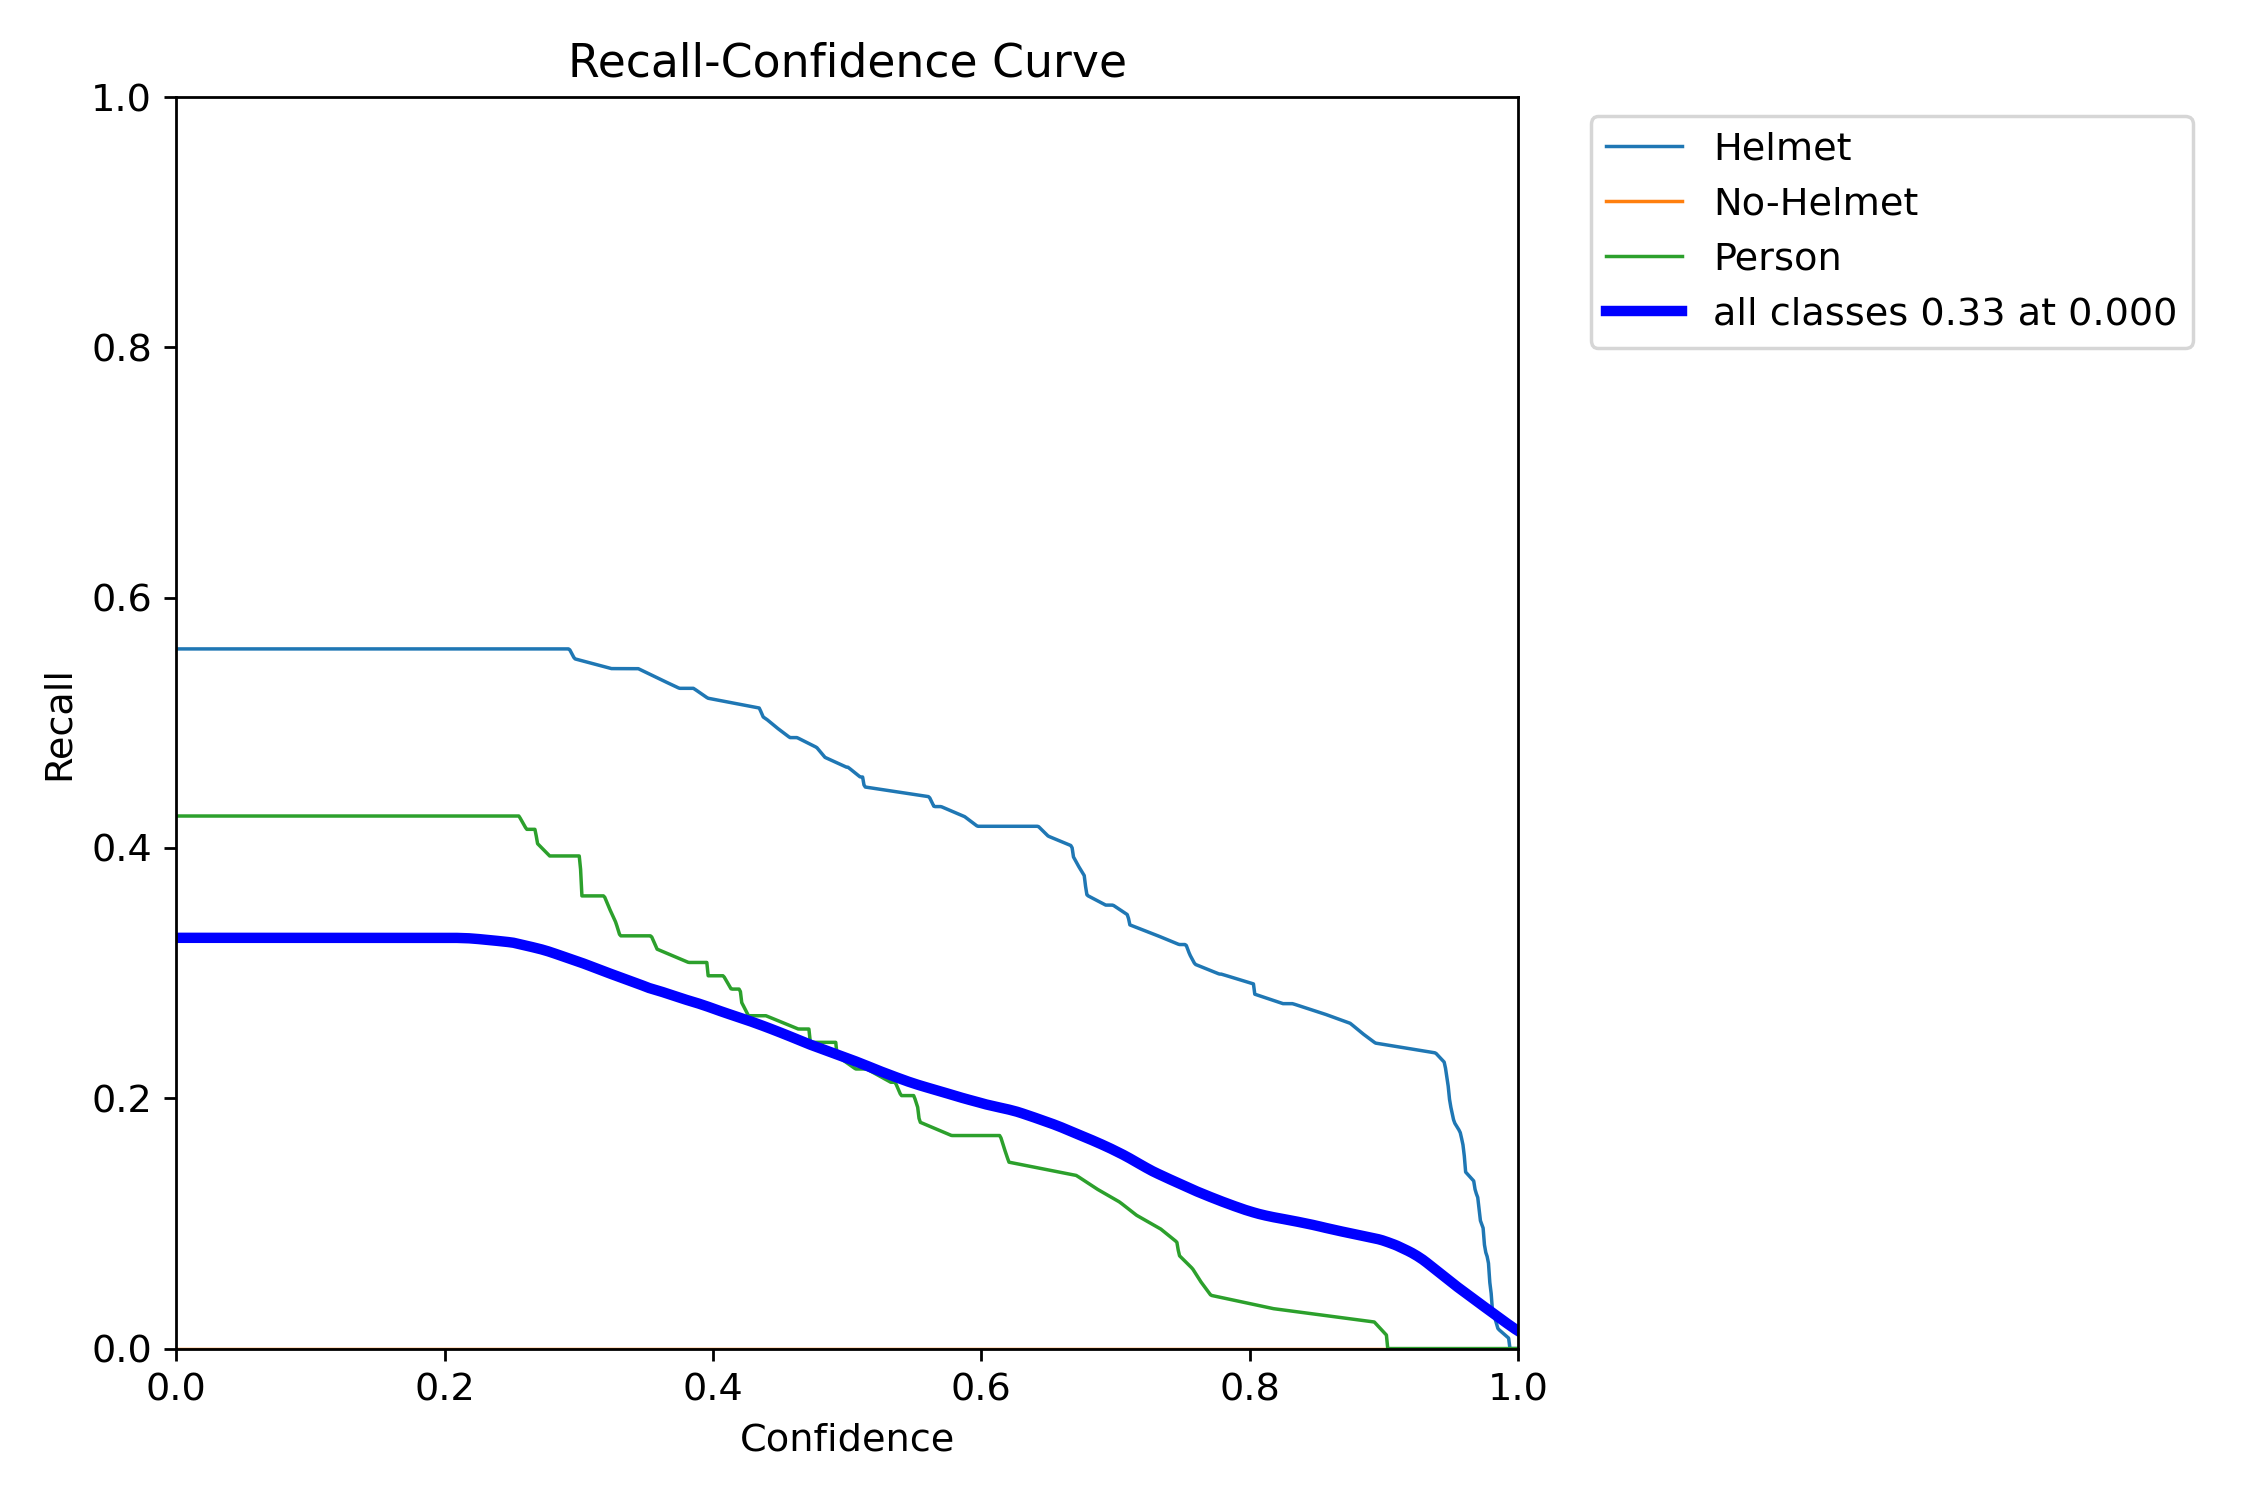

confusion_matrix.png


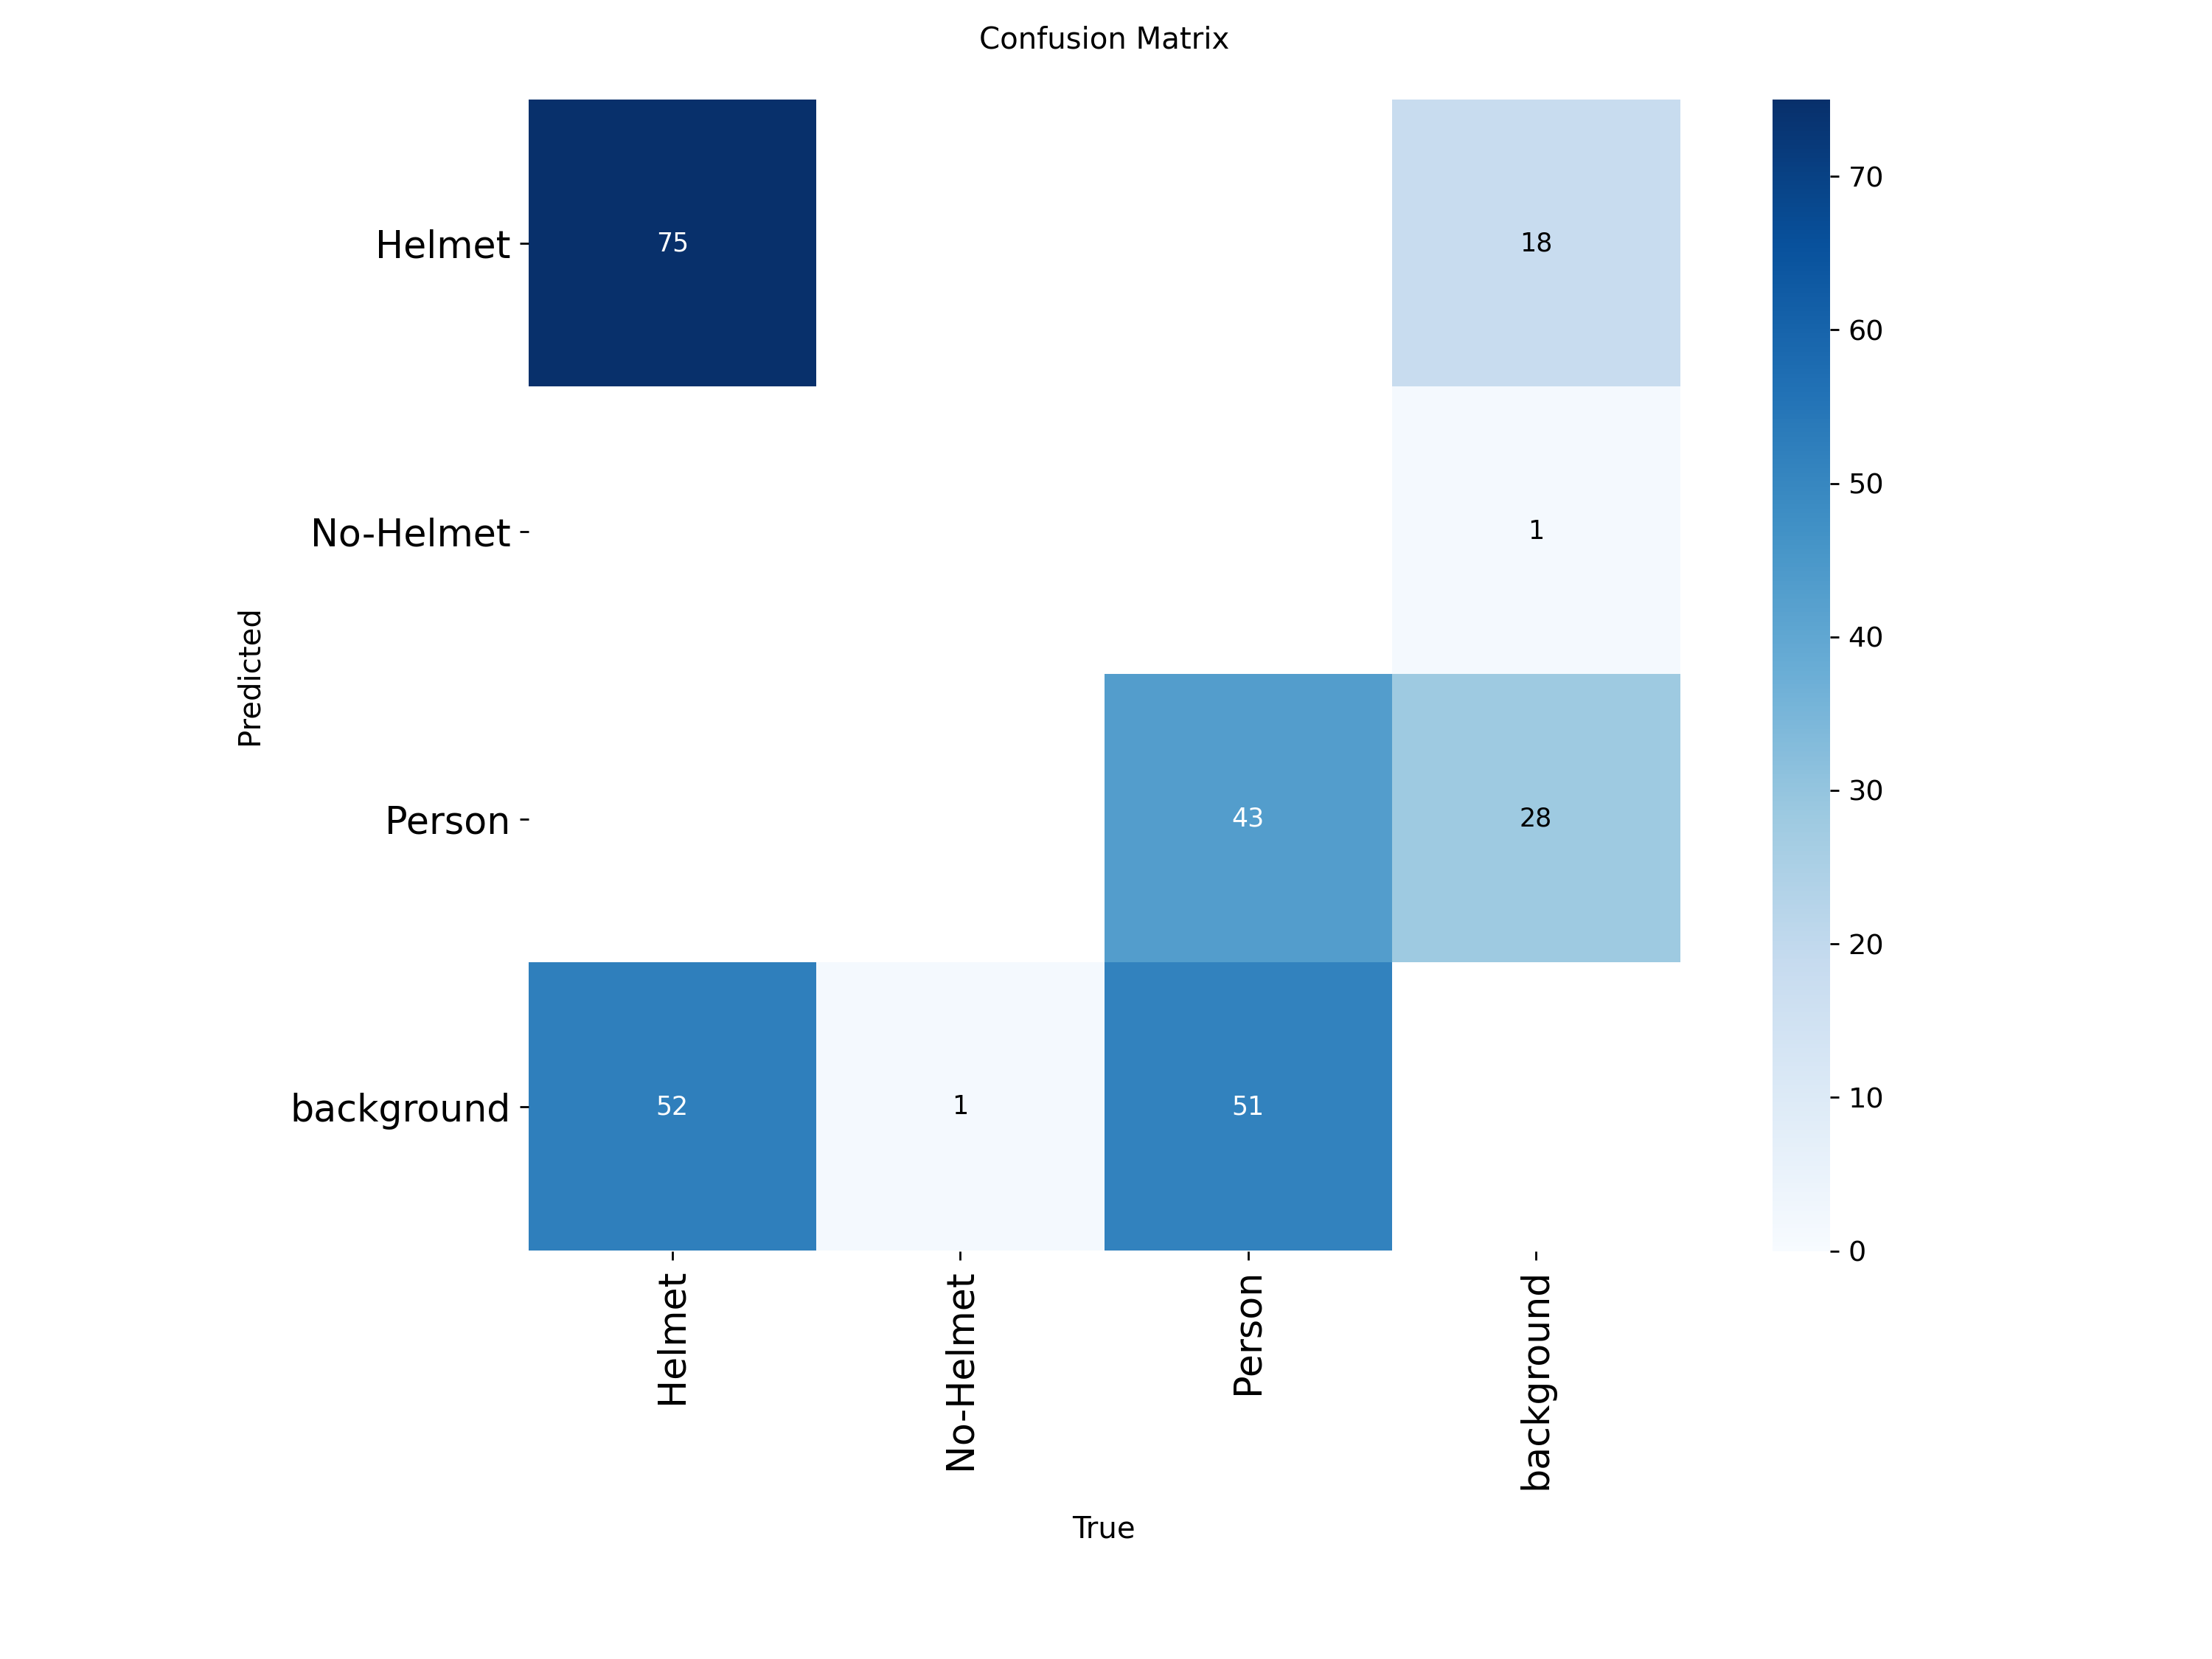

confusion_matrix_normalized.png


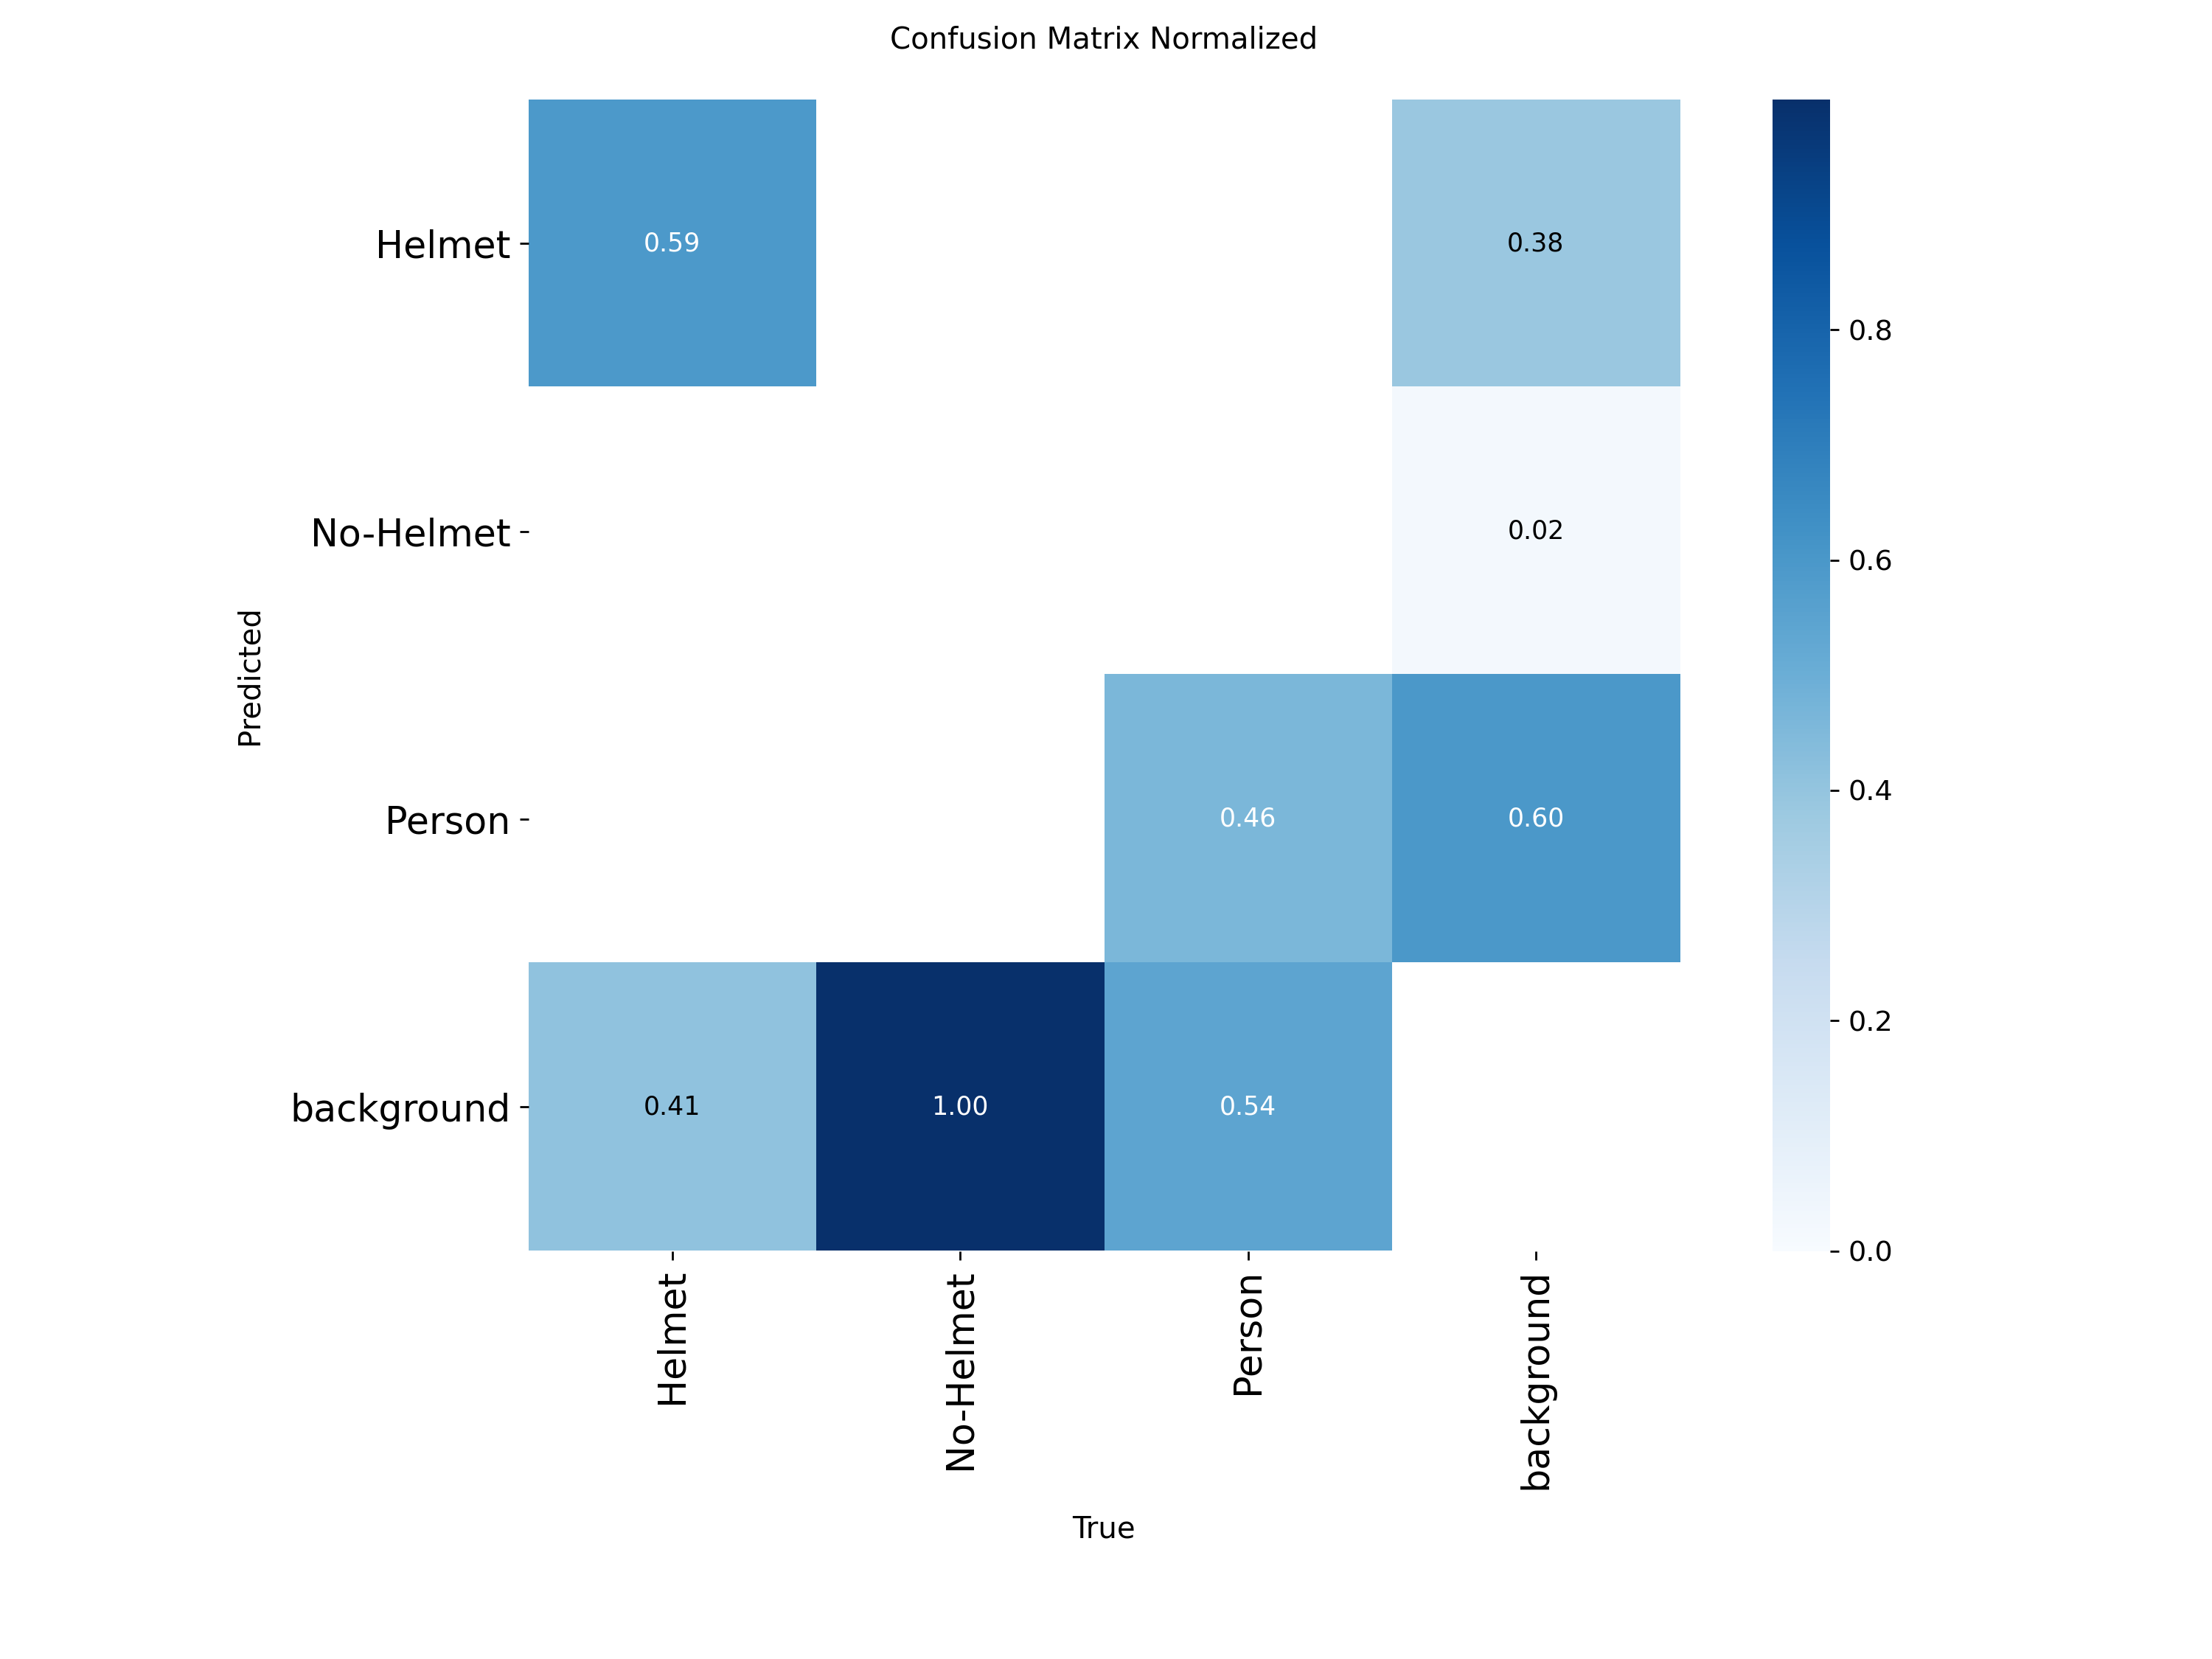

In [3]:
from pathlib import Path
from IPython.display import Image, display
shown = False
for sub in ["val", "test"]:
    d = Path("runs/evaluate") / sub
    if not d.exists(): continue
    pngs = sorted(list(d.glob("confusion_matrix*.png")) + list(d.glob("*_curve.png")))
    if pngs: print(f"=== {sub} ==="); shown = True
    for q in pngs:
        print(q.name); display(Image(filename=str(q)))
if not shown: print("Belum ada plot diagnostik - jalankan sel Run dulu.")

### c. Kumpulkan prediksi pada sampel validasi
Menjalankan model sekali pada sampel gambar val (conf rendah agar lengkap), mencocokkan ke ground-truth (IoU≥0.5). Hasilnya `pred_df`/`gt_df` dipakai analisis berikut.

In [4]:
from pathlib import Path
import numpy as np, random, pandas as pd
from PIL import Image
weights = Path("runs/train/helmet_yolo26s_baseline/weights/best.pt")
ANALYSIS_OK = True
try:
    from ultralytics import YOLO
    import eda
except Exception as e:
    ANALYSIS_OK = False; print("ultralytics belum ada:", e)
if ANALYSIS_OK and not weights.exists():
    ANALYSIS_OK = False; print("best.pt belum ada — latih model dulu (notebook 03).")
pred_df = gt_df = None; fp_ex = fn_ex = []
if ANALYSIS_OK:
    data, class_names, nc, root = eda.load_dataset_config("dataset/data.yaml")
    vimg, vlbl = eda.resolve_splits(root, data).get("valid", (None, None))
    SMALL, MED = eda.SMALL_AREA_THR, eda.MEDIUM_AREA_THR
    bucket = lambda a: "small" if a < SMALL else ("medium" if a < MED else "large")
    def load_gt(stem):
        f = vlbl/(stem+".txt"); out=[]
        if f.exists():
            for ln in f.read_text().splitlines():
                p = ln.split()
                if len(p)==5:
                    try: out.append((int(p[0]), *map(float, p[1:])))
                    except ValueError: pass
        return out
    def iou(a,b):
        ax1,ay1,ax2,ay2=a[0]-a[2]/2,a[1]-a[3]/2,a[0]+a[2]/2,a[1]+a[3]/2
        bx1,by1,bx2,by2=b[0]-b[2]/2,b[1]-b[3]/2,b[0]+b[2]/2,b[1]+b[3]/2
        iw=max(0,min(ax2,bx2)-max(ax1,bx1)); ih=max(0,min(ay2,by2)-max(ay1,by1))
        inter=iw*ih; ua=a[2]*a[3]+b[2]*b[3]-inter; return inter/ua if ua>0 else 0.0
    model = YOLO(str(weights), task="detect")
    imgs = sorted(p for p in vimg.iterdir() if p.suffix.lower() in {'.jpg','.jpeg','.png'})
    random.seed(0); sample = random.sample(imgs, min(80, len(imgs)))
    preds, gts = [], []
    for p in sample:
        gt = load_gt(p.stem)
        r = model.predict(str(p), conf=0.001, iou=0.6, imgsz=320, device="cpu", verbose=False)[0]
        pr = []
        if r.boxes is not None and len(r.boxes):
            for b,c,cf in zip(r.boxes.xywhn.tolist(), r.boxes.cls.tolist(), r.boxes.conf.tolist()):
                pr.append((int(c), b[0], b[1], b[2], b[3], float(cf)))
        pr.sort(key=lambda x: -x[5])
        matched, gt_conf = set(), {}
        tp_flags = []
        for (c,x,y,w,h,cf) in pr:
            best, bi = -1, -1
            for gi,g in enumerate(gt):
                if gi in matched or g[0] != c: continue
                v = iou((x,y,w,h), g[1:])
                if v > best: best, bi = v, gi
            tp = best >= 0.5
            if tp: matched.add(bi); gt_conf[bi] = cf
            tp_flags.append(tp)
            preds.append({"class": class_names[c], "conf": cf, "tp": tp,
                          "iou": best if best > 0 else 0.0, "size": bucket(w*h)})
        for gi,g in enumerate(gt):
            gts.append({"class": class_names[g[0]], "size": bucket(g[3]*g[4]),
                        "match_conf": gt_conf.get(gi, 0.0)})
        fps = [(c,x,y,w,h) for (c,x,y,w,h,cf), tp in zip(pr, tp_flags) if cf >= 0.25 and not tp]
        fns = [g for gi,g in enumerate(gt) if gi not in matched]
        if fps and len(fp_ex) < 3: fp_ex.append((p, fps))
        if fns and len(fn_ex) < 3: fn_ex.append((p, fns))
    pred_df = pd.DataFrame(preds); gt_df = pd.DataFrame(gts)
    print(f"terkumpul: {len(pred_df)} deteksi, {len(gt_df)} objek GT dari {len(sample)} gambar val")

terkumpul: 21642 deteksi, 490 objek GT dari 80 gambar val


### d. Sweep confidence threshold — *kenapa* `conf=0.25` (titik operasi)

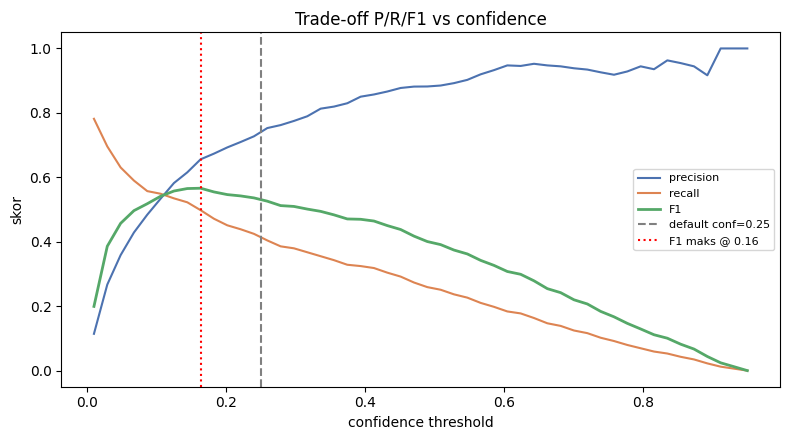

=> F1 maksimum di conf~0.16. Bandingkan dgn default 0.25 untuk pilih titik operasi.


In [5]:
import numpy as np, matplotlib.pyplot as plt
if pred_df is None or pred_df.empty:
    print("Jalankan sel (c) dulu / butuh model.")
else:
    total_gt = len(gt_df)
    ths = np.linspace(0.01, 0.95, 50); P, R, F = [], [], []
    conf = pred_df["conf"].values; tp = pred_df["tp"].values.astype(bool)
    for t in ths:
        sel = conf >= t; TP = (tp & sel).sum(); FP = ((~tp) & sel).sum()
        prec = TP/(TP+FP) if (TP+FP) else 1.0; rec = TP/total_gt if total_gt else 0.0
        P.append(prec); R.append(rec); F.append(2*prec*rec/(prec+rec) if (prec+rec) else 0.0)
    best_t = ths[int(np.argmax(F))]
    fig, ax = plt.subplots(figsize=(8,4.5))
    ax.plot(ths, P, label="precision", color="#4c72b0")
    ax.plot(ths, R, label="recall", color="#dd8452")
    ax.plot(ths, F, label="F1", color="#55a868", lw=2)
    ax.axvline(0.25, color="gray", ls="--", label="default conf=0.25")
    ax.axvline(best_t, color="red", ls=":", label=f"F1 maks @ {best_t:.2f}")
    ax.set_xlabel("confidence threshold"); ax.set_ylabel("skor"); ax.set_title("Trade-off P/R/F1 vs confidence")
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()
    print(f"=> F1 maksimum di conf~{best_t:.2f}. Bandingkan dgn default 0.25 untuk pilih titik operasi.")

### e. Recall per ukuran objek — *kenapa* objek kecil paling sering terlewat

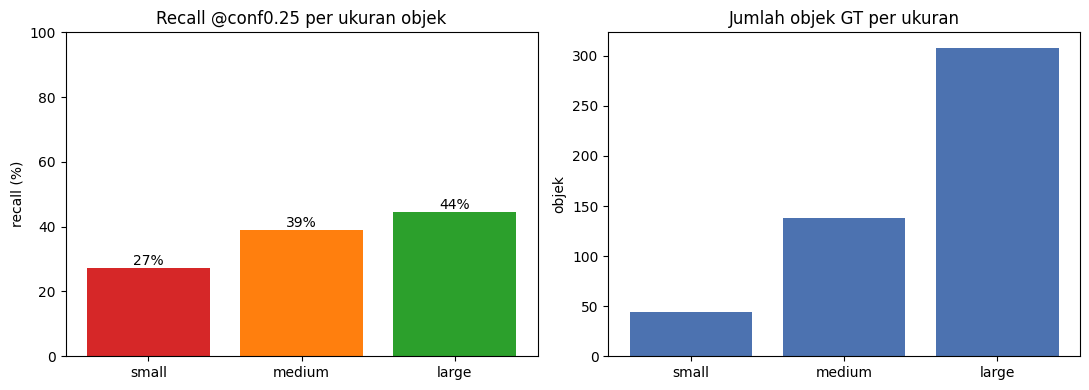

=> Recall 'small' rendah membuktikan objek kecil paling sulit (selaras EDA §3).


In [6]:
import matplotlib.pyplot as plt
if gt_df is None or gt_df.empty:
    print("Jalankan sel (c) dulu / butuh model.")
else:
    rec = gt_df.assign(detected=gt_df["match_conf"] >= 0.25).groupby("size")["detected"].mean().reindex(["small","medium","large"])
    cnt = gt_df["size"].value_counts().reindex(["small","medium","large"])
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    b = ax[0].bar(rec.index, (rec.values*100), color=["#d62728","#ff7f0e","#2ca02c"])
    for bb, v in zip(b, rec.values*100): ax[0].text(bb.get_x()+bb.get_width()/2, v, f"{v:.0f}%", ha="center", va="bottom")
    ax[0].set_title("Recall @conf0.25 per ukuran objek"); ax[0].set_ylabel("recall (%)"); ax[0].set_ylim(0,100)
    ax[1].bar(cnt.index, cnt.values, color="#4c72b0"); ax[1].set_title("Jumlah objek GT per ukuran"); ax[1].set_ylabel("objek")
    plt.tight_layout(); plt.show()
    print("=> Recall 'small' rendah membuktikan objek kecil paling sulit (selaras EDA §3).")

### f. Distribusi confidence TP vs FP & IoU — *kenapa* threshold memisahkan benar/salah

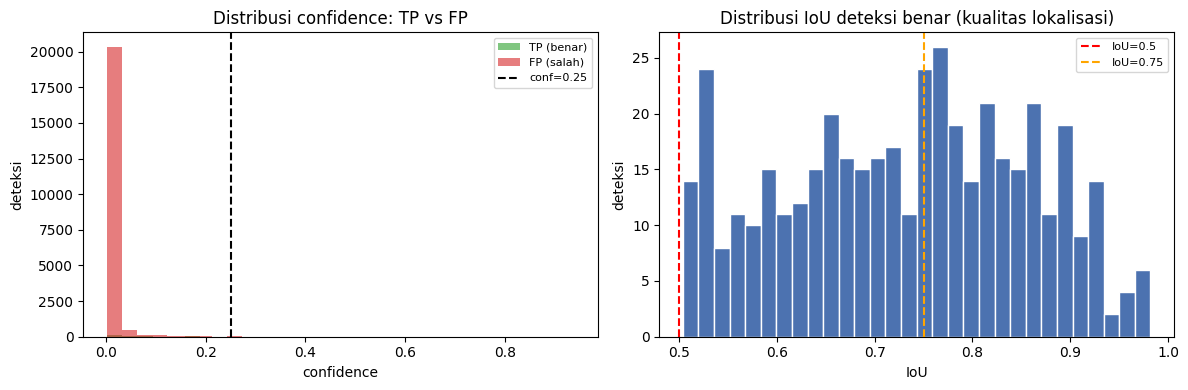

=> Banyak IoU dekat 0.5 menjelaskan gap mAP50 vs mAP50-95 (lokalisasi belum presisi).


In [7]:
import numpy as np, matplotlib.pyplot as plt
if pred_df is None or pred_df.empty:
    print("Jalankan sel (c) dulu / butuh model.")
else:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].hist(pred_df.loc[pred_df.tp, "conf"], bins=30, alpha=0.6, color="#2ca02c", label="TP (benar)")
    ax[0].hist(pred_df.loc[~pred_df.tp, "conf"], bins=30, alpha=0.6, color="#d62728", label="FP (salah)")
    ax[0].axvline(0.25, color="black", ls="--", label="conf=0.25")
    ax[0].set_title("Distribusi confidence: TP vs FP"); ax[0].set_xlabel("confidence"); ax[0].set_ylabel("deteksi"); ax[0].legend(fontsize=8)
    tp_iou = pred_df.loc[pred_df.tp, "iou"]
    ax[1].hist(tp_iou, bins=30, color="#4c72b0", edgecolor="white")
    ax[1].axvline(0.5, color="red", ls="--", label="IoU=0.5"); ax[1].axvline(0.75, color="orange", ls="--", label="IoU=0.75")
    ax[1].set_title("Distribusi IoU deteksi benar (kualitas lokalisasi)"); ax[1].set_xlabel("IoU"); ax[1].set_ylabel("deteksi"); ax[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()
    print("=> Banyak IoU dekat 0.5 menjelaskan gap mAP50 vs mAP50-95 (lokalisasi belum presisi).")

### g. Contoh False Positive & False Negative — *melihat* kesalahan model

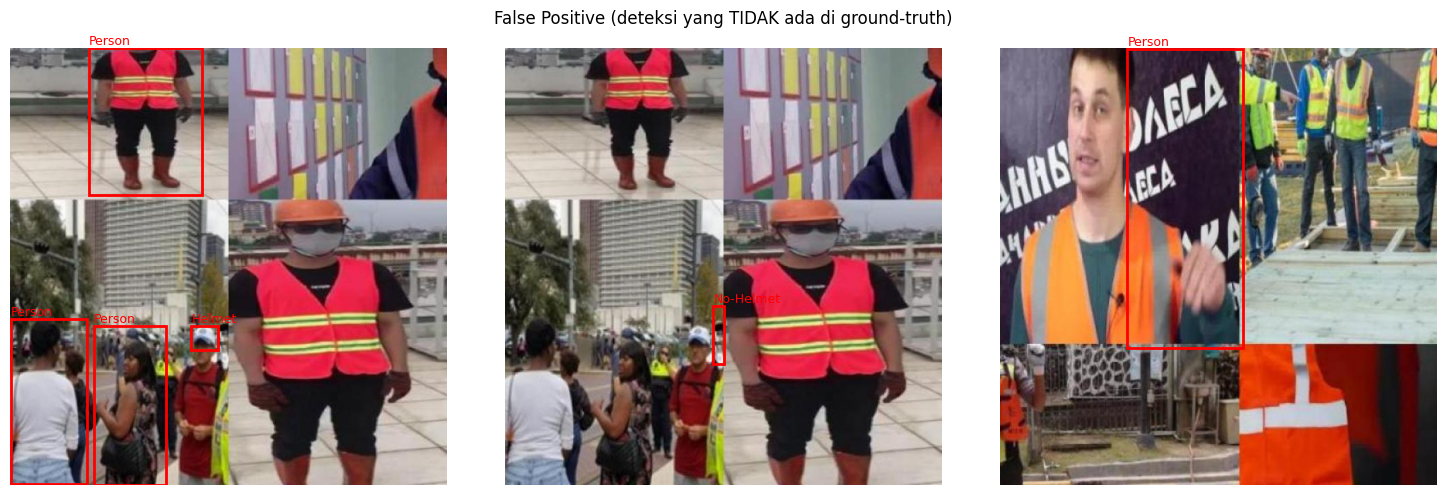

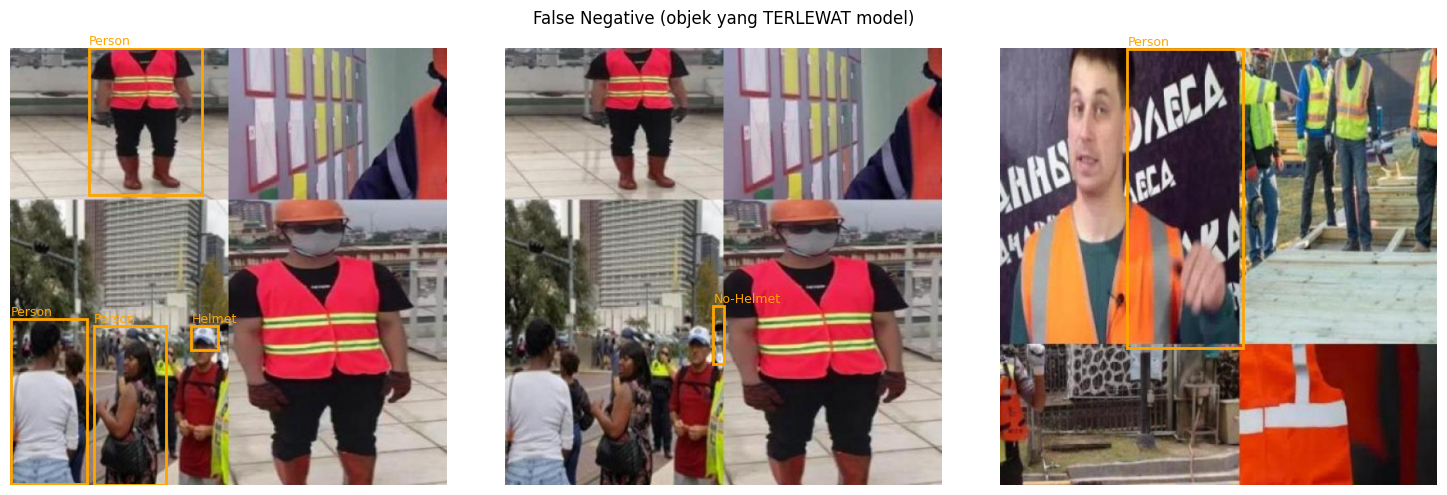

=> FP -> precision turun; FN -> recall turun.


In [8]:
import numpy as np, matplotlib.pyplot as plt, matplotlib.patches as mpatches
from PIL import Image
def montage(title, items, color):
    if not items: print("Tidak ada contoh untuk:", title); return
    fig, axes = plt.subplots(1, len(items), figsize=(5*len(items), 5)); axes = np.atleast_1d(axes)
    for ax, (p, boxes) in zip(axes, items):
        im = Image.open(p).convert("RGB"); W, H = im.size; ax.imshow(im)
        for c, x, y, w, h in boxes:
            ax.add_patch(mpatches.Rectangle(((x-w/2)*W, (y-h/2)*H), w*W, h*H, fill=False, edgecolor=color, lw=2))
            ax.text((x-w/2)*W, (y-h/2)*H, class_names[c], color=color, fontsize=9, va="bottom")
        ax.axis("off")
    fig.suptitle(title); plt.tight_layout(); plt.show()
if pred_df is None:
    print("Jalankan sel (c) dulu / butuh model.")
else:
    montage("False Positive (deteksi yang TIDAK ada di ground-truth)", fp_ex, "red")
    montage("False Negative (objek yang TERLEWAT model)", fn_ex, "orange")
    print("=> FP -> precision turun; FN -> recall turun.")